# PEG_PCL Degradation 

In [1]:
%run ../../../setup_workspace.py # ../ means level up 
from scipy.interpolate import interp1d

# Functions

In [2]:
def linear(x, k, b):
    return k * x + b
    
def linear_2points(x, x1, y1, x2, y2):
    k = (y2 - y1) / (x2 - x1)
    b = y1 - k * x1

    return linear(x, k, b)

def linear_2(x, y, i1, i2):
    x1 = x[i1]
    y1 = y[i1]
    x2 = x[i2]
    y2 = y[i2]
    return linear_2points(x, x1, y1, x2, y2)

def gaussian(x, A, x0, sigma):
    return A * np.exp(-(x - x0)**2 / (2 * sigma**2))

def voigt(x, A, x0, sigma, gamma):
    return A * voigt_profile(x - x0, sigma, gamma) / voigt_profile(0, sigma, gamma)

def shifted_interp(x, shift, ampl):
    f = interpolate.interp1d(q_amorph + shift, I_amorph, kind='cubic')
    return ampl * f(x + shift)

def const(x, C):
    return np.ones(len(x)) * C

# STATIC: Analysis

### M1

Linkam_empty_withoutCover_1m_1
PCL_M1_100ms_1m_1_T=70C


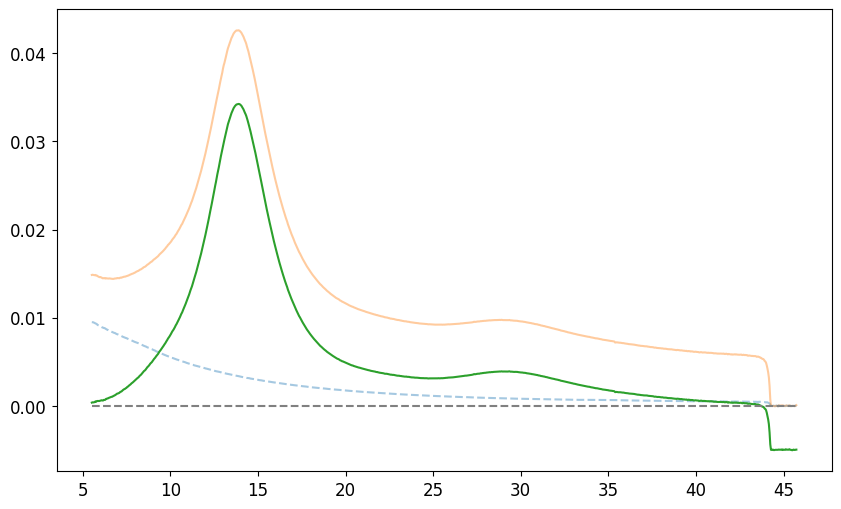

In [519]:
coef = 1

path = r"\\Synology\Data\2025\sc5665\id02\20250404\PROCESSED_DATA\PEG\PEG_20250405-141744\PEG_waxs_00063_00_ave.h5"
Exp = ID02_experiment(path)
print(Exp.get_Title())
q, I_bkg = Exp.get_1d_data()
plt.plot(q, coef * I_bkg, linestyle='--', alpha=0.4)


path = r"\\Synology\Data\2025\sc5665\id02\20250404\PROCESSED_DATA\PEG\PEG_20250405-141744\PEG_waxs_00075_00_ave.h5"
Exp = ID02_experiment(path)
q, I = Exp.get_1d_data()
print(Exp.get_Title())
plt.plot(q, I, alpha=0.4)

X_amorph, Y_amorph = q, I - coef * I_bkg
Y_amorph -= 0.9 * Y_amorph[10]

plt.plot(X_amorph, Y_amorph)
plt.plot(q, const(q, 0), linestyle='--', color='grey')

PCL_M1_100ms_1m_1


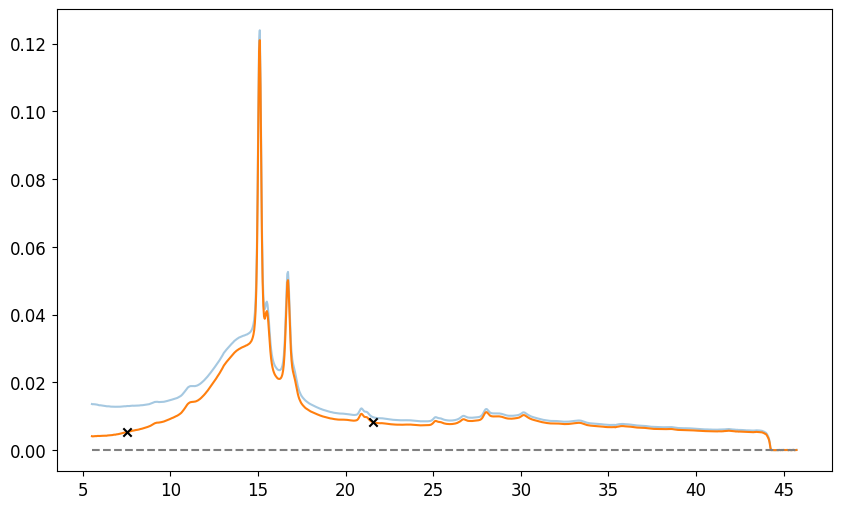

In [105]:

path = r"\\Synology\Data\2025\sc5665\id02\20250404\PROCESSED_DATA\PEG\PEG_20250405-141744\PEG_waxs_00071_00_ave.h5"
Exp = ID02_experiment(path)
q, I = Exp.get_1d_data()
print(Exp.get_Title())
plt.plot(q, I, alpha = 0.4)

X_cryst, Y_cryst = q, I - coef * I_bkg

plt.plot(X_cryst, Y_cryst)
plt.plot(q, const(q, 0), linestyle='--', color='grey')

interp = interp1d(X_amorph, Y_amorph, kind='cubic', bounds_error=False, fill_value=0)

def halo(x, shift, scale):
    q_shifted = x - shift
    I = interp(q_shifted)
    I[(q_shifted < q_amorph[0]) | (q_shifted > q_amorph[-1])] = 0
    return scale * I

func_lib_M1 = {
    'gaussian': gaussian,
    'voigt': voigt,
    'halo': halo,
    'const': const
}
l, r = 50, 400

X, Y = X_cryst[l:r], Y_cryst[l:r]
plt.scatter([X[0], X[-1]], [Y[0], Y[-1]], color='black', marker='x', zorder=19)

In [106]:
# Было:
f_M1 = Fitter(X, Y, func_lib_M1)

# Загружаем параметры из предыдущего фиттера (f_old)
# f_M1.set_params(f.get_params())

In [107]:
areas = f_M1.integrals()           # площади ∫ y dx
moments = f_M1.moments()            # моменты ∫ y * x² dx

All = np.sum(moments[1:])
Cr = np.sum(moments[2:])
Cr / All

np.float64(0.29189119214398584)

In [109]:
Cr_M1 = 0.29189119214398584

### M2

Linkam_empty_withoutCover_1m_1
PCL_M2_100ms_1m_1_T=70C


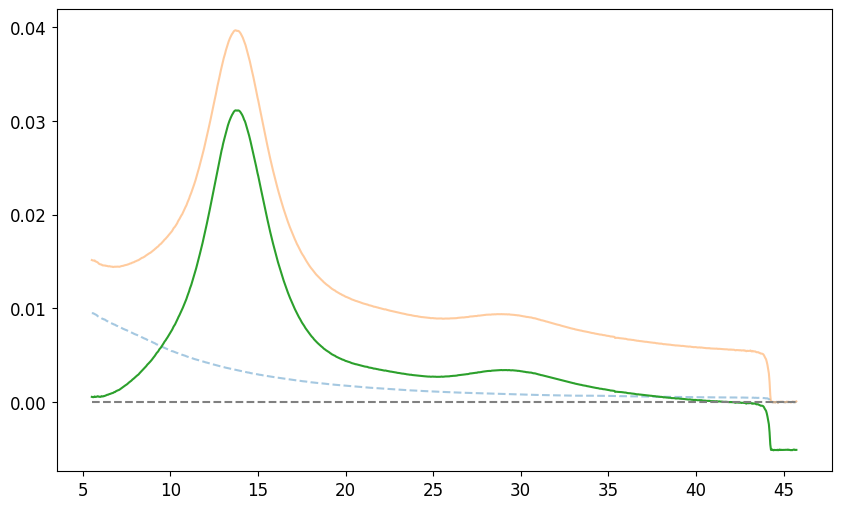

In [112]:
coef = 1

path = r"\\Synology\Data\2025\sc5665\id02\20250404\PROCESSED_DATA\PEG\PEG_20250405-141744\PEG_waxs_00063_00_ave.h5"
Exp = ID02_experiment(path)
print(Exp.get_Title())
q, I_bkg = Exp.get_1d_data()
plt.plot(q, coef * I_bkg, linestyle='--', alpha=0.4)


path = r"\\Synology\Data\2025\sc5665\id02\20250404\PROCESSED_DATA\PEG\PEG_20250405-141744\PEG_waxs_00088_00_ave.h5"
Exp = ID02_experiment(path)
q, I = Exp.get_1d_data()
print(Exp.get_Title())
plt.plot(q, I, alpha=0.4)

X_amorph, Y_amorph = q, I - coef * I_bkg
Y_amorph -= 0.9 * Y_amorph[10]

plt.plot(X_amorph, Y_amorph)
plt.plot(q, const(q, 0), linestyle='--', color='grey')

PCL_M2_100ms_1m_1


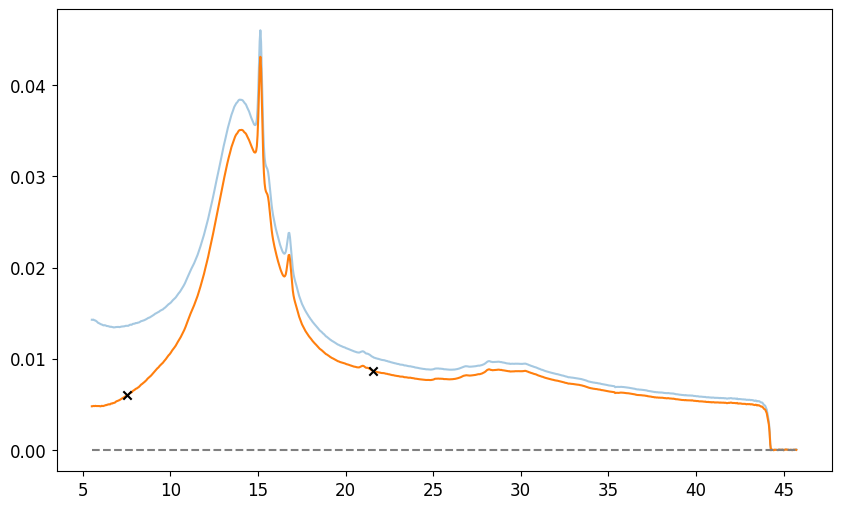

In [114]:

path = r"\\Synology\Data\2025\sc5665\id02\20250404\PROCESSED_DATA\PEG\PEG_20250405-141744\PEG_waxs_00083_00_ave.h5"
Exp = ID02_experiment(path)
q, I = Exp.get_1d_data()
print(Exp.get_Title())
plt.plot(q, I, alpha = 0.4)

X_cryst, Y_cryst = q, I - coef * I_bkg

plt.plot(X_cryst, Y_cryst)
plt.plot(q, const(q, 0), linestyle='--', color='grey')

interp = interp1d(X_amorph, Y_amorph, kind='cubic', bounds_error=False, fill_value=0)

def halo(x, shift, scale):
    q_shifted = x - shift
    I = interp(q_shifted)
    I[(q_shifted < q_amorph[0]) | (q_shifted > q_amorph[-1])] = 0
    return scale * I

func_lib_M2 = {
    'gaussian': gaussian,
    'voigt': voigt,
    'halo': halo,
    'const': const
}
l, r = 50, 400

X, Y = X_cryst[l:r], Y_cryst[l:r]
plt.scatter([X[0], X[-1]], [Y[0], Y[-1]], color='black', marker='x', zorder=19)

In [117]:
# Было:
f_M2 = Fitter(X, Y, func_lib_M2)

# Загружаем параметры из предыдущего фиттера (f_old)
f_M2.set_params(f_M1.get_params())

In [137]:
areas = f_M2.integrals()           # площади ∫ y dx
moments = f_M2.moments()            # моменты ∫ y * x² dx

All = np.sum(moments[1:])
Cr = np.sum(moments[2:])
Cr / All

np.float64(0.03182415178660963)

In [119]:
Cr_M2 =0.03510283919372445

### M3

Linkam_empty_withoutCover_1m_1
PCL_M3_100ms_1m_1_T=70C


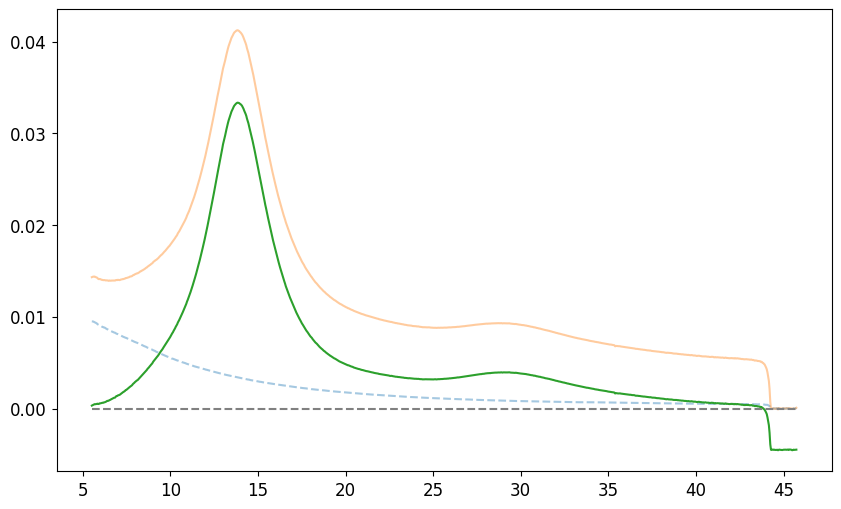

In [152]:
coef = 1

path = r"\\Synology\Data\2025\sc5665\id02\20250404\PROCESSED_DATA\PEG\PEG_20250405-141744\PEG_waxs_00063_00_ave.h5"
Exp = ID02_experiment(path)
print(Exp.get_Title())
q, I_bkg = Exp.get_1d_data()
plt.plot(q, coef * I_bkg, linestyle='--', alpha=0.4)


path = r"\\Synology\Data\2025\sc5665\id02\20250404\PROCESSED_DATA\PEG\PEG_20250405-141744\PEG_waxs_00099_00_ave.h5"
Exp = ID02_experiment(path)
q, I = Exp.get_1d_data()
print(Exp.get_Title())
plt.plot(q, I, alpha=0.4)

X_amorph, Y_amorph = q, I - coef * I_bkg
Y_amorph -= 0.9 * Y_amorph[10]

plt.plot(X_amorph, Y_amorph)
plt.plot(q, const(q, 0), linestyle='--', color='grey')

PCL_M3_100ms_1m_1


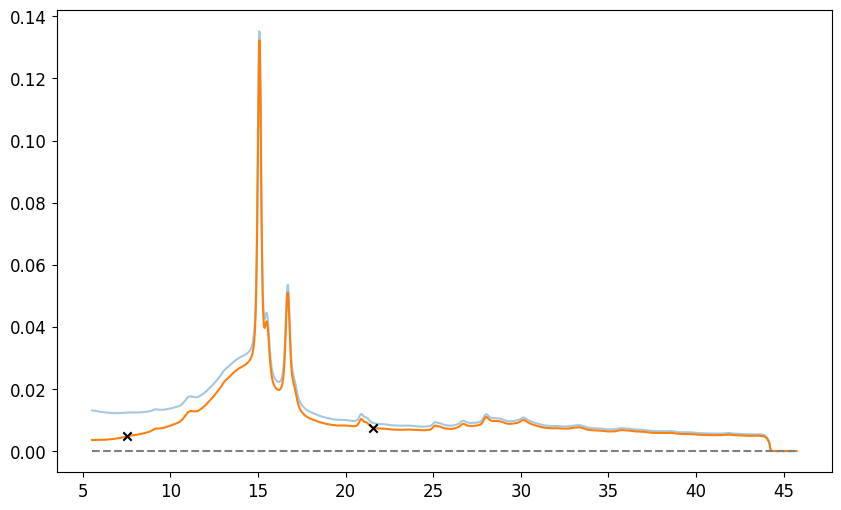

In [153]:

path = r"\\Synology\Data\2025\sc5665\id02\20250404\PROCESSED_DATA\PEG\PEG_20250405-141744\PEG_waxs_00096_00_ave.h5"
Exp = ID02_experiment(path)
q, I = Exp.get_1d_data()
print(Exp.get_Title())
plt.plot(q, I, alpha = 0.4)

X_cryst, Y_cryst = q, I - coef * I_bkg

plt.plot(X_cryst, Y_cryst)
plt.plot(q, const(q, 0), linestyle='--', color='grey')

interp = interp1d(X_amorph, Y_amorph, kind='cubic', bounds_error=False, fill_value=0)

def halo(x, shift, scale):
    q_shifted = x - shift
    I = interp(q_shifted)
    I[(q_shifted < q_amorph[0]) | (q_shifted > q_amorph[-1])] = 0
    return scale * I

func_lib_M3 = {
    'gaussian': gaussian,
    'voigt': voigt,
    'halo': halo,
    'const': const
}
l, r = 50, 400

X, Y = X_cryst[l:r], Y_cryst[l:r]
plt.scatter([X[0], X[-1]], [Y[0], Y[-1]], color='black', marker='x', zorder=19)

In [154]:
# Было:
f_M3 = Fitter(X, Y, func_lib_M3)

# Загружаем параметры из предыдущего фиттера (f_old)
f_M3.set_params(f_M1.get_params())

In [155]:
areas = f_M3.integrals()           # площади ∫ y dx
moments = f_M3.moments()            # моменты ∫ y * x² dx

All = np.sum(moments[1:])
Cr = np.sum(moments[2:])
Cr / All

np.float64(0.34709596843049345)

In [159]:
Cr_M3 = 0.34709596843049345 

### M4

Linkam_empty_withoutCover_1m_1
PCL_M4_100ms_1m_1_T=80C


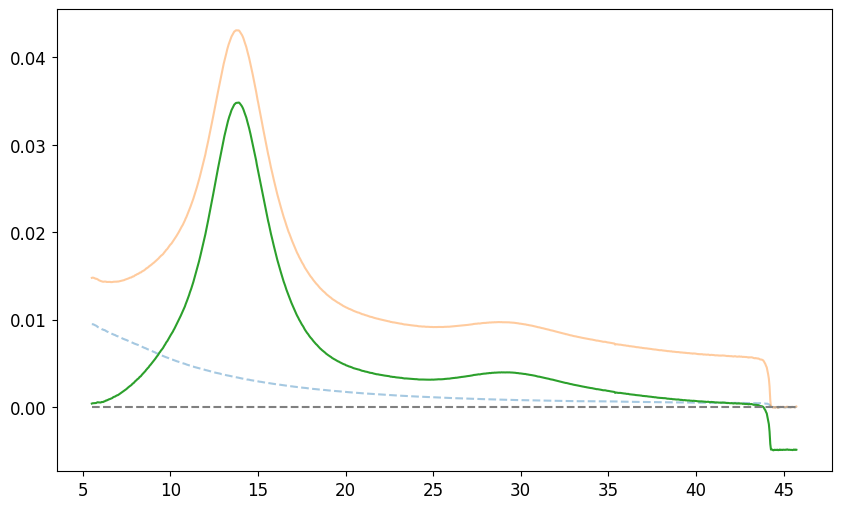

In [144]:
coef = 1

path = r"\\Synology\Data\2025\sc5665\id02\20250404\PROCESSED_DATA\PEG\PEG_20250405-141744\PEG_waxs_00063_00_ave.h5"
Exp = ID02_experiment(path)
print(Exp.get_Title())
q, I_bkg = Exp.get_1d_data()
plt.plot(q, coef * I_bkg, linestyle='--', alpha=0.4)


path = r"\\Synology\Data\2025\sc5665\id02\20250404\PROCESSED_DATA\PEG\PEG_20250405-141744\PEG_waxs_00112_00_ave.h5"
Exp = ID02_experiment(path)
q, I = Exp.get_1d_data()
print(Exp.get_Title())
plt.plot(q, I, alpha=0.4)

X_amorph, Y_amorph = q, I - coef * I_bkg
Y_amorph -= 0.9 * Y_amorph[10]

plt.plot(X_amorph, Y_amorph)
plt.plot(q, const(q, 0), linestyle='--', color='grey')

PCL_M4_100ms_1m_1


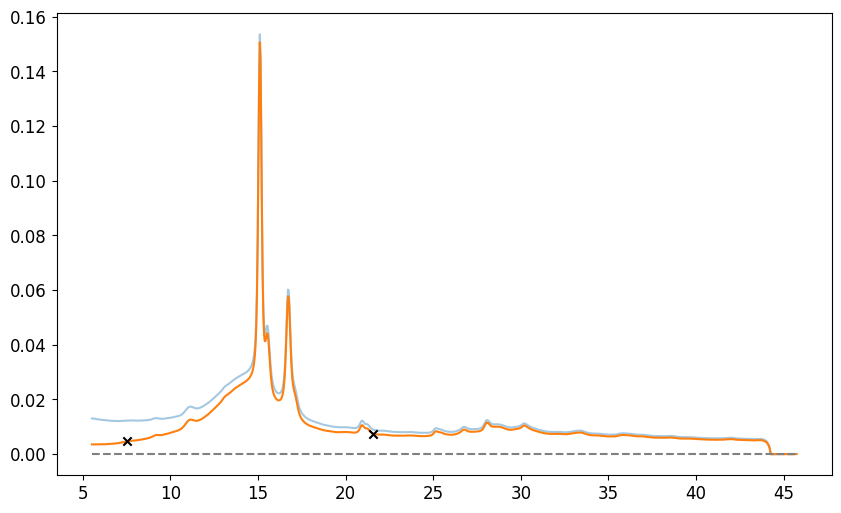

In [145]:
path = r"\\Synology\Data\2025\sc5665\id02\20250404\PROCESSED_DATA\PEG\PEG_20250405-141744\PEG_waxs_00108_00_ave.h5"
Exp = ID02_experiment(path)
q, I = Exp.get_1d_data()
print(Exp.get_Title())
plt.plot(q, I, alpha = 0.4)

X_cryst, Y_cryst = q, I - coef * I_bkg

plt.plot(X_cryst, Y_cryst)
plt.plot(q, const(q, 0), linestyle='--', color='grey')

interp = interp1d(X_amorph, Y_amorph, kind='cubic', bounds_error=False, fill_value=0)

def halo(x, shift, scale):
    q_shifted = x - shift
    I = interp(q_shifted)
    I[(q_shifted < q_amorph[0]) | (q_shifted > q_amorph[-1])] = 0
    return scale * I

func_lib_M4 = {
    'gaussian': gaussian,
    'voigt': voigt,
    'halo': halo,
    'const': const
}
l, r = 50, 400

X, Y = X_cryst[l:r], Y_cryst[l:r]
plt.scatter([X[0], X[-1]], [Y[0], Y[-1]], color='black', marker='x', zorder=19)

In [146]:
# Было:
f_M4 = Fitter(X, Y, func_lib_M4)

# Загружаем параметры из предыдущего фиттера (f_old)
f_M4.set_params(f_M1.get_params())

In [148]:
areas = f_M4.integrals()           # площади ∫ y dx
moments = f_M4.moments()            # моменты ∫ y * x² dx

All = np.sum(moments[1:])
Cr = np.sum(moments[2:])
Cr / All

np.float64(0.41020142940955306)

### M3_PEG 20%

Linkam_empty_withoutCover_1m_1
M3_PEG_20perc_100ms_65C


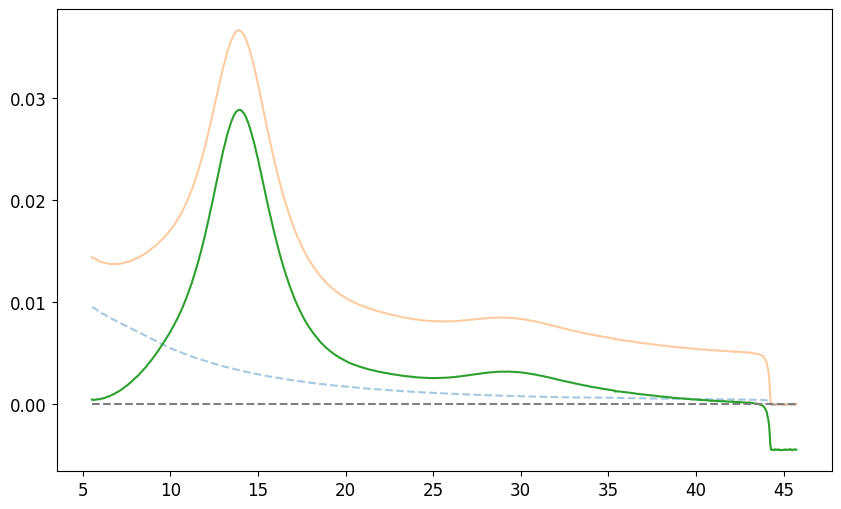

In [165]:
coef = 1

path = r"\\Synology\Data\2025\sc5665\id02\20250404\PROCESSED_DATA\PEG\PEG_20250405-141744\PEG_waxs_00063_00_ave.h5"
Exp = ID02_experiment(path)
print(Exp.get_Title())
q, I_bkg = Exp.get_1d_data()
plt.plot(q, coef * I_bkg, linestyle='--', alpha=0.4)


path = r"\\Synology\Data\2025\sc5665\id02\20250404\PROCESSED_DATA\PEG\PEG_20250405-141744\PEG_waxs_00053_00_ave.h5"
Exp = ID02_experiment(path)
q, I = Exp.get_1d_data()
print(Exp.get_Title())
plt.plot(q, I, alpha=0.4)

X_amorph, Y_amorph = q, I - coef * I_bkg
Y_amorph -= 0.9 * Y_amorph[10]

plt.plot(X_amorph, Y_amorph)
plt.plot(q, const(q, 0), linestyle='--', color='grey')

M3_PEG_20perc_100ms


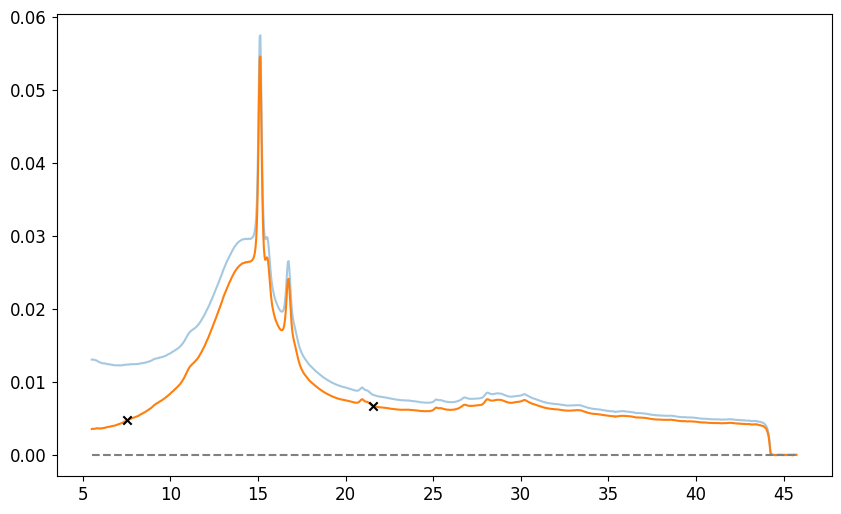

In [161]:

path = r"\\Synology\Data\2025\sc5665\id02\20250404\PROCESSED_DATA\PEG\PEG_20250405-141744\PEG_waxs_00052_00_ave.h5"
Exp = ID02_experiment(path)
q, I = Exp.get_1d_data()
print(Exp.get_Title())
plt.plot(q, I, alpha = 0.4)

X_cryst, Y_cryst = q, I - coef * I_bkg

plt.plot(X_cryst, Y_cryst)
plt.plot(q, const(q, 0), linestyle='--', color='grey')

interp = interp1d(X_amorph, Y_amorph, kind='cubic', bounds_error=False, fill_value=0)

def halo(x, shift, scale):
    q_shifted = x - shift
    I = interp(q_shifted)
    I[(q_shifted < q_amorph[0]) | (q_shifted > q_amorph[-1])] = 0
    return scale * I

func_lib_M3_20perc = {
    'gaussian': gaussian,
    'voigt': voigt,
    'halo': halo,
    'const': const
}
l, r = 50, 400

X, Y = X_cryst[l:r], Y_cryst[l:r]
plt.scatter([X[0], X[-1]], [Y[0], Y[-1]], color='black', marker='x', zorder=19)

In [162]:
# Было:
f_M3_20perc = Fitter(X, Y, func_lib_M3_20perc)

# Загружаем параметры из предыдущего фиттера (f_old)
f_M3_20perc.set_params(f_M3.get_params())

In [163]:
areas = f_M3_20perc.integrals()           # площади ∫ y dx
moments = f_M3_20perc.moments()            # моменты ∫ y * x² dx

All = np.sum(moments[1:])
Cr = np.sum(moments[2:])
Cr / All

np.float64(0.212804394610691)

### M3_PEG 15%

Linkam_empty_withoutCover_1m_1
M3_PEG_20perc_100ms_65C


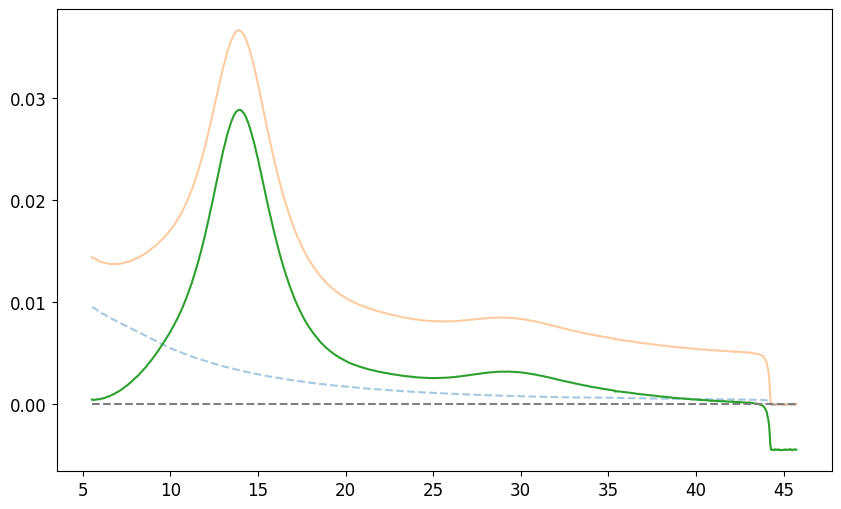

In [172]:
coef = 1

path = r"\\Synology\Data\2025\sc5665\id02\20250404\PROCESSED_DATA\PEG\PEG_20250405-141744\PEG_waxs_00063_00_ave.h5"
Exp = ID02_experiment(path)
print(Exp.get_Title())
q, I_bkg = Exp.get_1d_data()
plt.plot(q, coef * I_bkg, linestyle='--', alpha=0.4)


path = r"\\Synology\Data\2025\sc5665\id02\20250404\PROCESSED_DATA\PEG\PEG_20250405-141744\PEG_waxs_00053_00_ave.h5"
Exp = ID02_experiment(path)
q, I = Exp.get_1d_data()
print(Exp.get_Title())
plt.plot(q, I, alpha=0.4)

X_amorph, Y_amorph = q, I - coef * I_bkg
Y_amorph -= 0.9 * Y_amorph[10]

plt.plot(X_amorph, Y_amorph)
plt.plot(q, const(q, 0), linestyle='--', color='grey')

M3_PEG_15perc_100ms


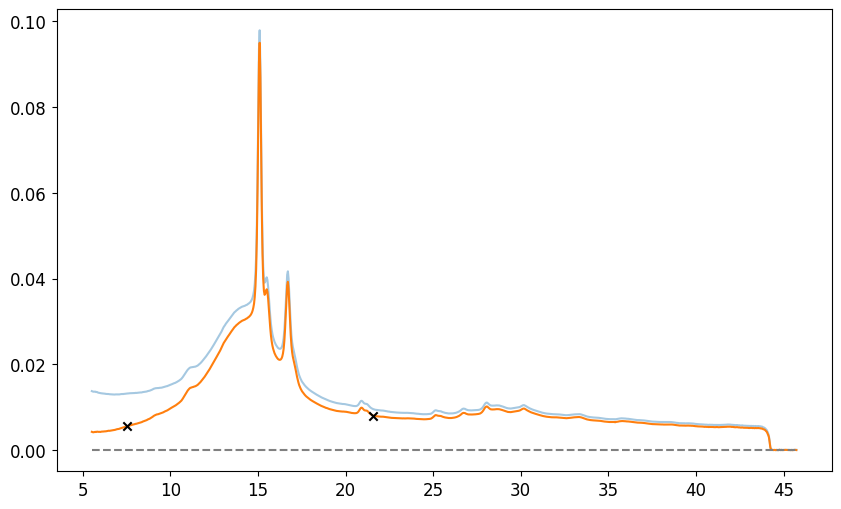

In [174]:

path = r"\\Synology\Data\2025\sc5665\id02\20250404\PROCESSED_DATA\PEG\PEG_20250405-141744\PEG_waxs_00045_00_ave.h5"
Exp = ID02_experiment(path)
q, I = Exp.get_1d_data()
print(Exp.get_Title())
plt.plot(q, I, alpha = 0.4)

X_cryst, Y_cryst = q, I - coef * I_bkg

plt.plot(X_cryst, Y_cryst)
plt.plot(q, const(q, 0), linestyle='--', color='grey')

interp = interp1d(X_amorph, Y_amorph, kind='cubic', bounds_error=False, fill_value=0)

def halo(x, shift, scale):
    q_shifted = x - shift
    I = interp(q_shifted)
    I[(q_shifted < q_amorph[0]) | (q_shifted > q_amorph[-1])] = 0
    return scale * I

func_lib_M3_15perc = {
    'gaussian': gaussian,
    'voigt': voigt,
    'halo': halo,
    'const': const
}
l, r = 50, 400

X, Y = X_cryst[l:r], Y_cryst[l:r]
plt.scatter([X[0], X[-1]], [Y[0], Y[-1]], color='black', marker='x', zorder=19)

In [175]:
# Было:
f_M3_15perc = Fitter(X, Y, func_lib_M3_15perc)

# Загружаем параметры из предыдущего фиттера (f_old)
f_M3_15perc.set_params(f_M3.get_params())

In [176]:
areas = f_M3_15perc.integrals()           # площади ∫ y dx
moments = f_M3_15perc.moments()            # моменты ∫ y * x² dx

All = np.sum(moments[1:])
Cr = np.sum(moments[2:])
Cr / All

np.float64(0.24060187668039076)

### M3_PEG 10%

Linkam_empty_withoutCover_1m_1
M3_PEG_20perc_100ms_65C


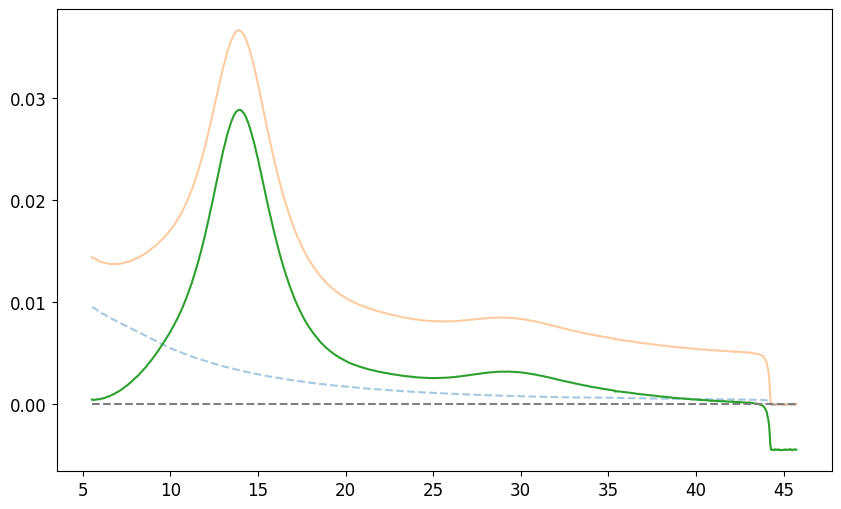

In [177]:
coef = 1

path = r"\\Synology\Data\2025\sc5665\id02\20250404\PROCESSED_DATA\PEG\PEG_20250405-141744\PEG_waxs_00063_00_ave.h5"
Exp = ID02_experiment(path)
print(Exp.get_Title())
q, I_bkg = Exp.get_1d_data()
plt.plot(q, coef * I_bkg, linestyle='--', alpha=0.4)


path = r"\\Synology\Data\2025\sc5665\id02\20250404\PROCESSED_DATA\PEG\PEG_20250405-141744\PEG_waxs_00053_00_ave.h5"
Exp = ID02_experiment(path)
q, I = Exp.get_1d_data()
print(Exp.get_Title())
plt.plot(q, I, alpha=0.4)

X_amorph, Y_amorph = q, I - coef * I_bkg
Y_amorph -= 0.9 * Y_amorph[10]

plt.plot(X_amorph, Y_amorph)
plt.plot(q, const(q, 0), linestyle='--', color='grey')

M3_PEG_10perc_100ms


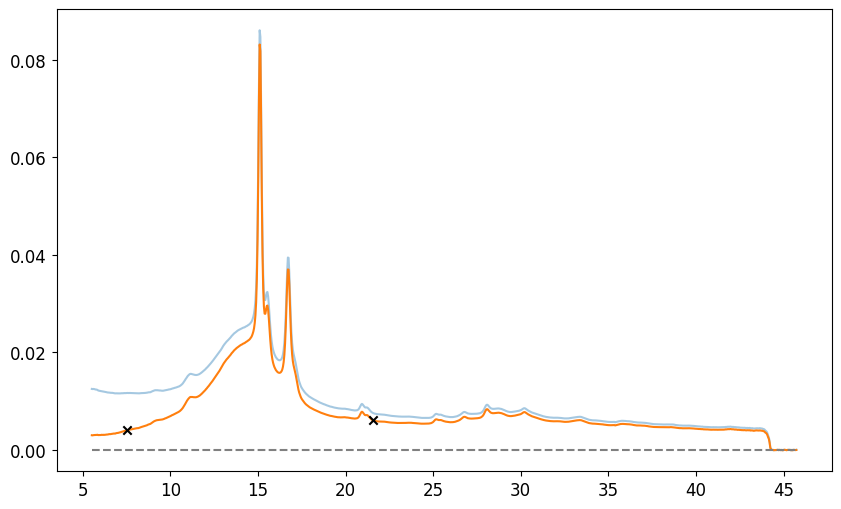

In [179]:

path = r"\\Synology\Data\2025\sc5665\id02\20250404\PROCESSED_DATA\PEG\PEG_20250405-141744\PEG_waxs_00038_00_ave.h5"
Exp = ID02_experiment(path)
q, I = Exp.get_1d_data()
print(Exp.get_Title())
plt.plot(q, I, alpha = 0.4)

X_cryst, Y_cryst = q, I - coef * I_bkg

plt.plot(X_cryst, Y_cryst)
plt.plot(q, const(q, 0), linestyle='--', color='grey')

interp = interp1d(X_amorph, Y_amorph, kind='cubic', bounds_error=False, fill_value=0)

def halo(x, shift, scale):
    q_shifted = x - shift
    I = interp(q_shifted)
    I[(q_shifted < q_amorph[0]) | (q_shifted > q_amorph[-1])] = 0
    return scale * I

func_lib_M3_10perc = {
    'gaussian': gaussian,
    'voigt': voigt,
    'halo': halo,
    'const': const
}
l, r = 50, 400

X, Y = X_cryst[l:r], Y_cryst[l:r]
plt.scatter([X[0], X[-1]], [Y[0], Y[-1]], color='black', marker='x', zorder=19)

In [180]:
# Было:
f_M3_10perc = Fitter(X, Y, func_lib_M3_10perc)

# Загружаем параметры из предыдущего фиттера (f_old)
f_M3_10perc.set_params(f_M3.get_params())

In [181]:
areas = f_M3_10perc.integrals()           # площади ∫ y dx
moments = f_M3_10perc.moments()            # моменты ∫ y * x² dx

All = np.sum(moments[1:])
Cr = np.sum(moments[2:])
Cr / All

np.float64(0.28606723655270005)

### M3_PEG 5%

Linkam_empty_withoutCover_1m_1
M3_PEG_20perc_100ms_65C


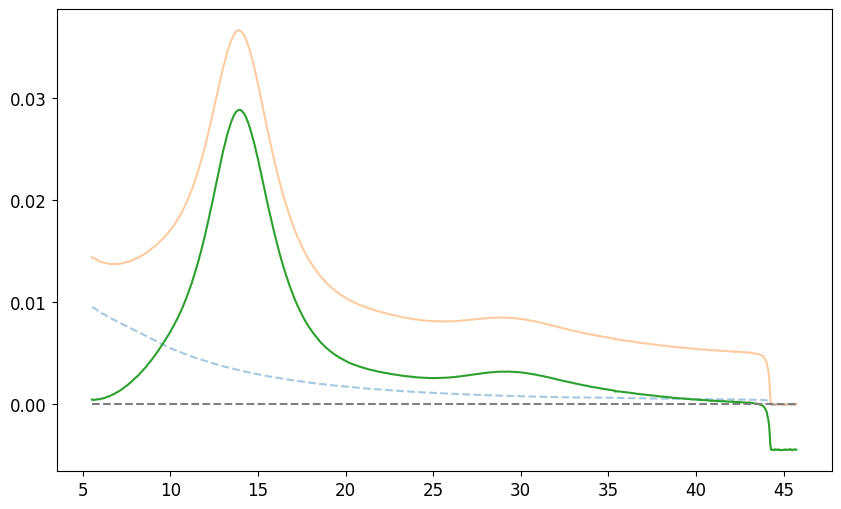

In [183]:
coef = 1

path = r"\\Synology\Data\2025\sc5665\id02\20250404\PROCESSED_DATA\PEG\PEG_20250405-141744\PEG_waxs_00063_00_ave.h5"
Exp = ID02_experiment(path)
print(Exp.get_Title())
q, I_bkg = Exp.get_1d_data()
plt.plot(q, coef * I_bkg, linestyle='--', alpha=0.4)


path = r"\\Synology\Data\2025\sc5665\id02\20250404\PROCESSED_DATA\PEG\PEG_20250405-141744\PEG_waxs_00053_00_ave.h5"
Exp = ID02_experiment(path)
q, I = Exp.get_1d_data()
print(Exp.get_Title())
plt.plot(q, I, alpha=0.4)

X_amorph, Y_amorph = q, I - coef * I_bkg
Y_amorph -= 0.9 * Y_amorph[10]

plt.plot(X_amorph, Y_amorph)
plt.plot(q, const(q, 0), linestyle='--', color='grey')

M3_PEG_5perc_100ms


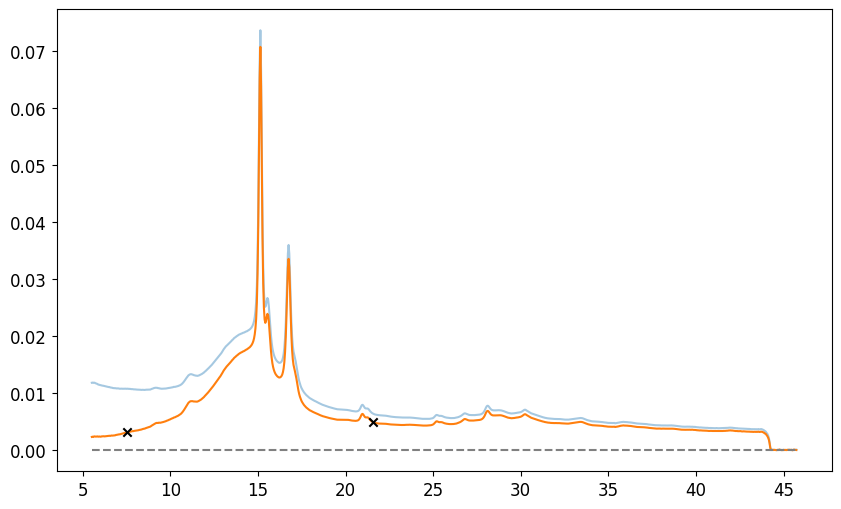

In [186]:

path = r"\\Synology\Data\2025\sc5665\id02\20250404\PROCESSED_DATA\PEG\PEG_20250405-141744\PEG_waxs_00029_00_ave.h5"
Exp = ID02_experiment(path)
q, I = Exp.get_1d_data()
print(Exp.get_Title())
plt.plot(q, I, alpha = 0.4)

X_cryst, Y_cryst = q, I - coef * I_bkg

plt.plot(X_cryst, Y_cryst)
plt.plot(q, const(q, 0), linestyle='--', color='grey')

interp = interp1d(X_amorph, Y_amorph, kind='cubic', bounds_error=False, fill_value=0)

def halo(x, shift, scale):
    q_shifted = x - shift
    I = interp(q_shifted)
    I[(q_shifted < q_amorph[0]) | (q_shifted > q_amorph[-1])] = 0
    return scale * I

func_lib_M3_5perc = {
    'gaussian': gaussian,
    'voigt': voigt,
    'halo': halo,
    'const': const
}
l, r = 50, 400

X, Y = X_cryst[l:r], Y_cryst[l:r]
plt.scatter([X[0], X[-1]], [Y[0], Y[-1]], color='black', marker='x', zorder=19)

In [187]:
# Было:
f_M3_5perc = Fitter(X, Y, func_lib_M3_5perc)

# Загружаем параметры из предыдущего фиттера (f_old)
f_M3_5perc.set_params(f_M3.get_params())

In [188]:
areas = f_M3_5perc.integrals()           # площади ∫ y dx
moments = f_M3_5perc.moments()            # моменты ∫ y * x² dx

All = np.sum(moments[1:])
Cr = np.sum(moments[2:])
Cr / All

np.float64(0.3076577883375812)

# DEGRADATION: Analysis

In [3]:
def scatter(x,y, index):
    for i in index:
        plt.scatter(x[i], y[i], marker='x', color='black', zorder=10)

def plot(x, y):
    fig = go.Figure()
    fig.add_trace(go.Scatter(x=x, y=y, mode='lines', name='SAXS'))
    fig.show()

from scipy.interpolate import CubicSpline
from scipy.interpolate import UnivariateSpline
from scipy.interpolate import PchipInterpolator

def cryst(X, Y, background, alpha):
    Cr = np.trapezoid((Y - background) * X ** 2, X) 
    All = np.trapezoid(Y * X ** 2, X)
    Amorph = Cr - All
    return Cr / All


In [4]:
path = r'E:\PEG_PCL\Alina_data\Degradation'

# Список файлов и папок
contents = os.listdir(path)

filtered = [f for f in contents if '90C' not in f and os.path.isdir(os.path.join(path, f))]


df = pd.DataFrame({'Exp':filtered})

Cr = []
for i in range(len(filtered)):
    full_path = os.path.join(path, filtered[i])
    Exp = BM26_experiment(full_path)
    try:
        q, I = Exp.get_1d_WAXS()
        l, r = 200, 1150
        I -= linear_2(q, I, l, r)
    
        X = q[l:r]
        Y = I[l:r]
    
        l1, r1 = 220, 300
        l2, r2 = 530, 660
        l3, r3 = 690, 780
    
    
        mask_peaks = np.ones_like(X, dtype=bool)
        for l, r in [(l1, r1), (l2, r2), (l3, r3)]:
            mask_peaks &= ~((X >= X[l]) & (X <= X[r]))
    
        background = np.interp(X, X[mask_peaks], Y[mask_peaks])
    
        Cr.append(cryst(X, Y, background))
    except:
        print(full_path)
        Cr.append(0)

df['Cr'] = Cr

E:\PEG_PCL\Alina_data\Degradation\Degradation_PCL_10_14days_RT
No available WAXS .dat files
E:\PEG_PCL\Alina_data\Degradation\Degradation_PCL_10_14D_RT
E:\PEG_PCL\Alina_data\Degradation\Degradation_PCL_10_3days_RT
E:\PEG_PCL\Alina_data\Degradation\Degradation_PCL_10_3d_RT
E:\PEG_PCL\Alina_data\Degradation\Degradation_PCL_10_6days_0C_aftermelt
E:\PEG_PCL\Alina_data\Degradation\Degradation_PCL_10_6d_RT
E:\PEG_PCL\Alina_data\Degradation\Degradation_PCL_15perc_14days_RT
E:\PEG_PCL\Alina_data\Degradation\Degradation_PCL_15perc_3days_RT
E:\PEG_PCL\Alina_data\Degradation\Degradation_PCL_15perc_6days_RT
E:\PEG_PCL\Alina_data\Degradation\Degradation_PCL_20perc_14days_RT
E:\PEG_PCL\Alina_data\Degradation\Degradation_PCL_20perc_3days_RT
E:\PEG_PCL\Alina_data\Degradation\Degradation_PCL_20perc_6days_RT
E:\PEG_PCL\Alina_data\Degradation\Degradation_PCL_5perc_14days_RT
E:\PEG_PCL\Alina_data\Degradation\Degradation_PCL_5perc_3days_RT
E:\PEG_PCL\Alina_data\Degradation\Degradation_PCL_5perc_6days_RT
E:

In [5]:
pd.read_table(path, skiprows=30, names=['q', 'I'], sep='    ')

C:\Users\LabPCA\AppData\Local\Temp\ipykernel_9364\569721384.py:1: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  pd.read_table(path, skiprows=30, names=['q', 'I'], sep='    ')


PermissionError: [Errno 13] Permission denied: 'E:\\PEG_PCL\\Alina_data\\Degradation'

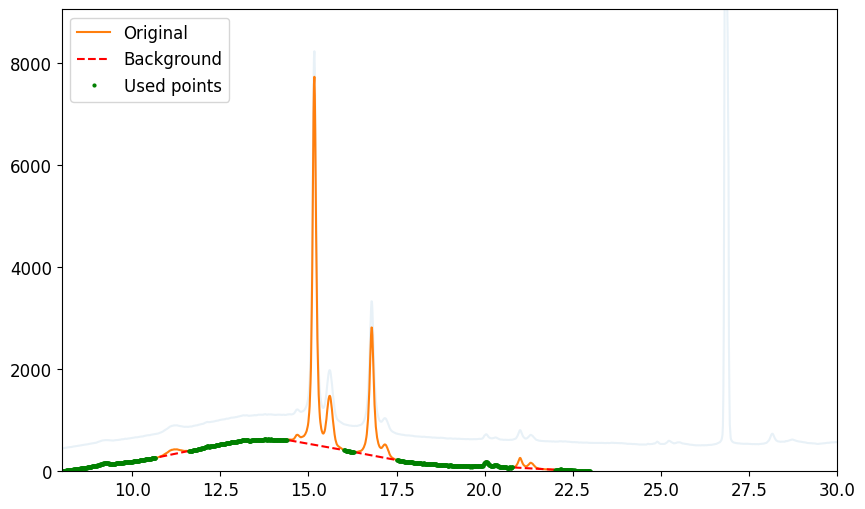

0.44593571201548055


In [95]:
path = r"E:\PEG_PCL\Alina_data\Additional\Degradation_PCL_20perc_14days_RT_WAXS_0004.dat"
# Exp = BM26_experiment(path)
# df = pd.read_table(path, skiprows=30, names=['q', 'I', ''], sep='    ')
df = pd.read_table(path, skiprows=1, names=['q', 'I', 'err'], sep=' ')
q, I = np.array(df['q']), np.array(df['I'])

alpha = 0.2

plt.plot(q, I, alpha=0.1)
l, r = 7.97, 23
mask = (q > l) * (q < r)

X = q[mask]
Y = I[mask]

Y -= linear_2points(X, X[0], Y[0], X[-1], Y[-1])

plt.xlim(8, 30)
plt.ylim(0, 1.1 * max(I[:1000]))

l1, r1 = 10.66, 11.6
l2, r2 = 14.4, 16.0
l3, r3 = 16.3, 17.5
l4, r4 = 20.8, 22

mask_peaks = np.ones_like(X, dtype=bool)
for l, r in [(l1, r1), (l2, r2), (l3, r3), 
             (l4, r4)
            ]:
    mask_peaks &= ~((X >= l) & (X <= r))

background = np.interp(X, X[mask_peaks], Y[mask_peaks])


plt.plot(X, Y, label='Original')
plt.plot(X, background, 'r--', label='Background')
plt.plot(X[mask_peaks], Y[mask_peaks], 'go', markersize=2, label='Used points')
plt.xlim(8, 30)
plt.legend()
plt.show()

Cr = cryst(X, Y, background, alpha)
print(Cr / (1- alpha))

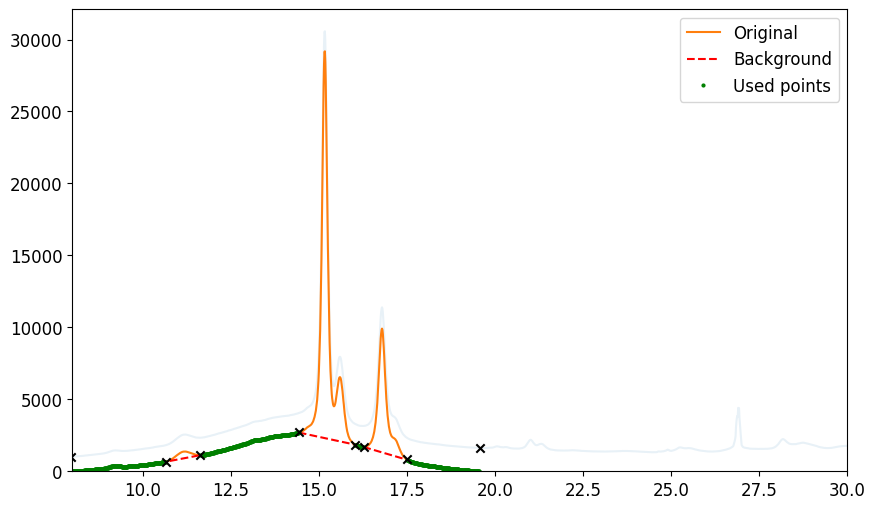

0.49309576660398075


In [63]:
path = r'E:\PEG_PCL\degradation\Degradation_PCL_20perc_6days_RT'
Exp = BM26_experiment(path)
alpha = 0.05

q, I = Exp.get_1d_WAXS(0)

plt.plot(q, I, alpha=0.1)
l, r = 200, 1150
scatter(q, I, [l, r])
I -= linear_2(q, I, l, r)

X = q[l:r]
Y = I[l:r]

plt.xlim(8, 30)
plt.ylim(0, 1.1 * max(I[:1000]))

l1, r1 = 220, 300
l2, r2 = 530, 660
l3, r3 = 680, 780
# l4, r4 = 1030, 1130

scatter(X, Y, [l1, r1, l2, r2, l3, r3, 
               # l4, r4
              ])


mask_peaks = np.ones_like(X, dtype=bool)
for l, r in [(l1, r1), (l2, r2), (l3, r3), 
             # (l4, r4)
            ]:
    mask_peaks &= ~((X >= X[l]) & (X <= X[r]))

spline = PchipInterpolator(X[mask_peaks], Y[mask_peaks], 
                    
                          # extrapolate=False
                         )
# background = spline(q)
background = np.interp(X, X[mask_peaks], Y[mask_peaks])


plt.plot(X, Y, label='Original')
plt.plot(X, background, 'r--', label='Background')
plt.plot(X[mask_peaks], Y[mask_peaks], 'go', markersize=2, label='Used points')
plt.xlim(8, 30)
plt.legend()
plt.show()

Cr = cryst(X, Y, background, alpha)
print(Cr / (1 - alpha))

### M1

##### 3 days

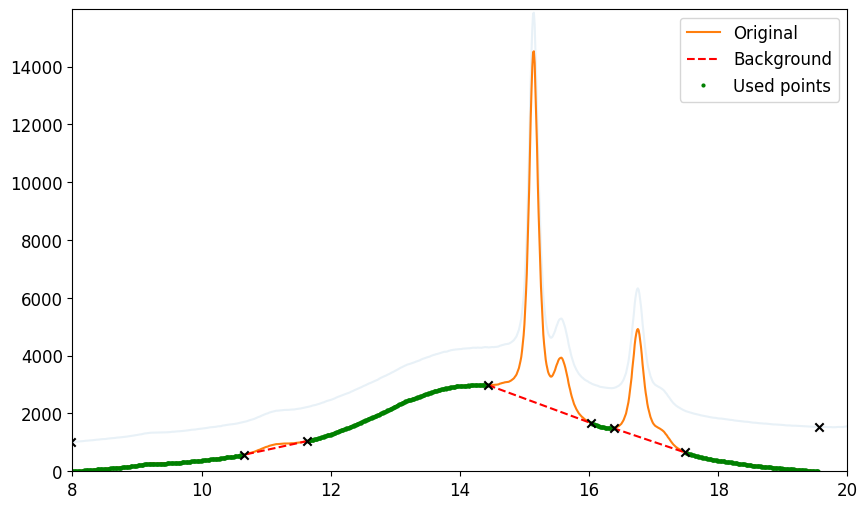

np.float64(0.271724509605645)

In [556]:
path = r'\\Synology\Data\2025\SC5711\Degradation\Degradation_PCL_M1_3daysRT'
Exp = BM26_experiment(path)
q, I = Exp.get_1d_WAXS(2)

plt.plot(q, I, alpha=0.1)
l, r = 200, 1150
scatter(q, I, [l, r])
I -= linear_2(q, I, l, r)

X = q[l:r]
Y = I[l:r]

plt.xlim(8, 20)
plt.ylim(0, 1.1 * max(I[:1000]))

l1, r1 = 220, 300
l2, r2 = 530, 660
l3, r3 = 690, 780

scatter(X, Y, [l1, r1, l2, r2, l3, r3])


mask_peaks = np.ones_like(X, dtype=bool)
for l, r in [(l1, r1), (l2, r2), (l3, r3)]:
    mask_peaks &= ~((X >= X[l]) & (X <= X[r]))

spline = PchipInterpolator(X[mask_peaks], Y[mask_peaks], 
                    
                          # extrapolate=False
                         )
# background = spline(q)
background = np.interp(X, X[mask_peaks], Y[mask_peaks])


plt.plot(X, Y, label='Original')
plt.plot(X, background, 'r--', label='Background')
plt.plot(X[mask_peaks], Y[mask_peaks], 'go', markersize=2, label='Used points')
plt.xlim(8, 20)
plt.legend()
plt.show()

cryst(X, Y, background)

np.float64(0.271724509605645)

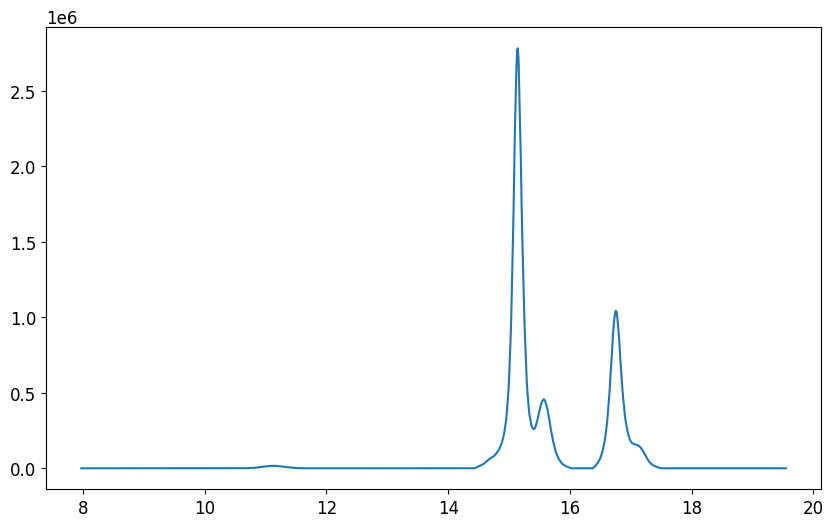

In [544]:
plt.plot(X, (Y - background )* X ** 2)
np.trapezoid((Y - background) * X ** 2, X) / np.trapezoid(Y * X ** 2, X)



##### 6 days

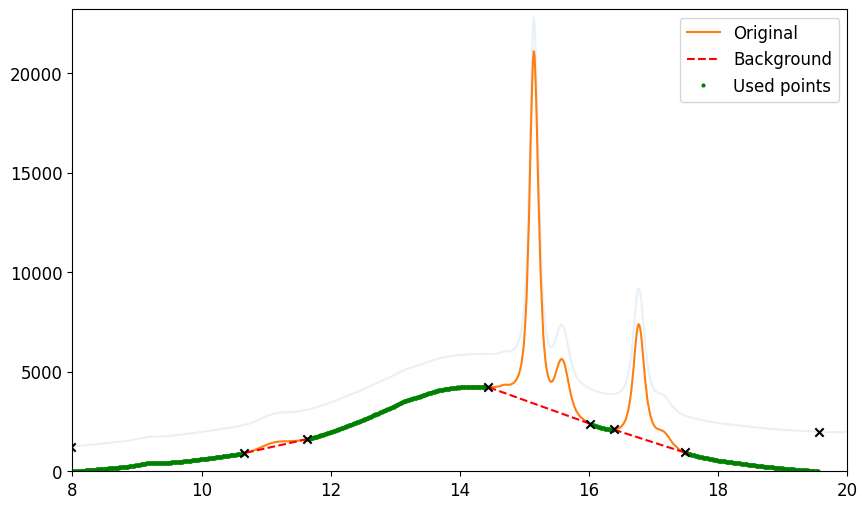

np.float64(0.268776269507325)

In [557]:
path = r'\\Synology\Data\2025\SC5711\Degradation\Degradation_PCL_M1_6daysRT'
Exp = BM26_experiment(path)
q, I = Exp.get_1d_WAXS(0)

plt.plot(q, I, alpha=0.1)
l, r = 200, 1150
scatter(q, I, [l, r])
I -= linear_2(q, I, l, r)

X = q[l:r]
Y = I[l:r]

plt.xlim(8, 20)
plt.ylim(0, 1.1 * max(I[:1000]))

l1, r1 = 220, 300
l2, r2 = 530, 660
l3, r3 = 690, 780

scatter(X, Y, [l1, r1, l2, r2, l3, r3])


mask_peaks = np.ones_like(X, dtype=bool)
for l, r in [(l1, r1), (l2, r2), (l3, r3)]:
    mask_peaks &= ~((X >= X[l]) & (X <= X[r]))

spline = PchipInterpolator(X[mask_peaks], Y[mask_peaks], 
                    
                          # extrapolate=False
                         )
# background = spline(q)
background = np.interp(X, X[mask_peaks], Y[mask_peaks])


plt.plot(X, Y, label='Original')
plt.plot(X, background, 'r--', label='Background')
plt.plot(X[mask_peaks], Y[mask_peaks], 'go', markersize=2, label='Used points')
plt.xlim(8, 20)
plt.legend()
plt.show()

cryst(X, Y, background)

np.float64(0.268776269507325)

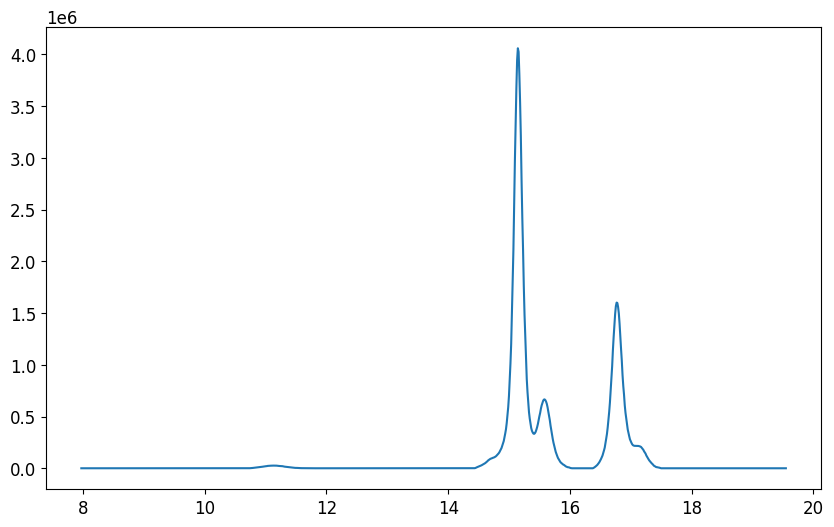

In [548]:
plt.plot(X, (Y - background )* X ** 2)
np.trapezoid((Y - background) * X ** 2, X) / np.trapezoid(Y * X ** 2, X)



### M3 5%

##### 3 days

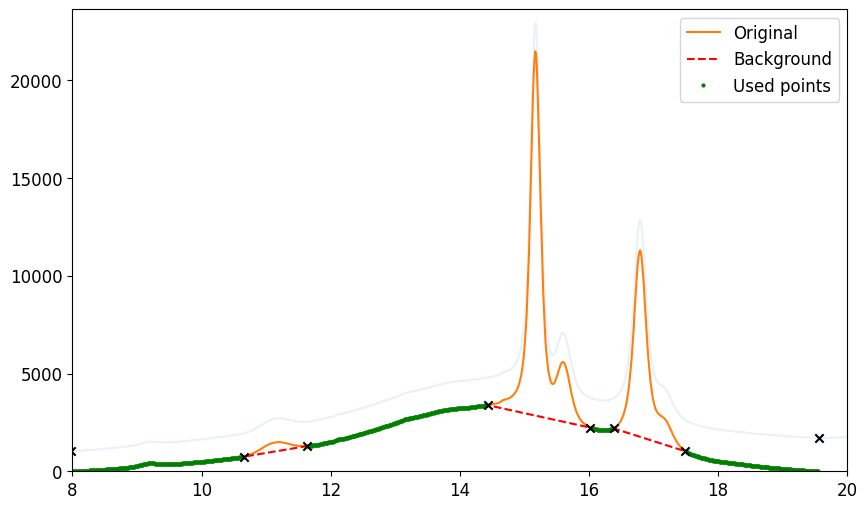

np.float64(0.37477533536806046)

In [558]:
path = r'\\Synology\Data\2025\SC5711\Degradation\Degradation_PCL_5perc_3days_RT'
Exp = BM26_experiment(path)
q, I = Exp.get_1d_WAXS(2)

plt.plot(q, I, alpha=0.1)
l, r = 200, 1150
scatter(q, I, [l, r])
I -= linear_2(q, I, l, r)

X = q[l:r]
Y = I[l:r]

plt.xlim(8, 20)
plt.ylim(0, 1.1 * max(I[:1000]))

l1, r1 = 220, 300
l2, r2 = 530, 660
l3, r3 = 690, 780

scatter(X, Y, [l1, r1, l2, r2, l3, r3])


mask_peaks = np.ones_like(X, dtype=bool)
for l, r in [(l1, r1), (l2, r2), (l3, r3)]:
    mask_peaks &= ~((X >= X[l]) & (X <= X[r]))

spline = PchipInterpolator(X[mask_peaks], Y[mask_peaks], 
                    
                          # extrapolate=False
                         )
# background = spline(q)
background = np.interp(X, X[mask_peaks], Y[mask_peaks])


plt.plot(X, Y, label='Original')
plt.plot(X, background, 'r--', label='Background')
plt.plot(X[mask_peaks], Y[mask_peaks], 'go', markersize=2, label='Used points')
plt.xlim(8, 20)
plt.legend()
plt.show()

cryst(X, Y, background)

np.float64(0.37477533536806046)

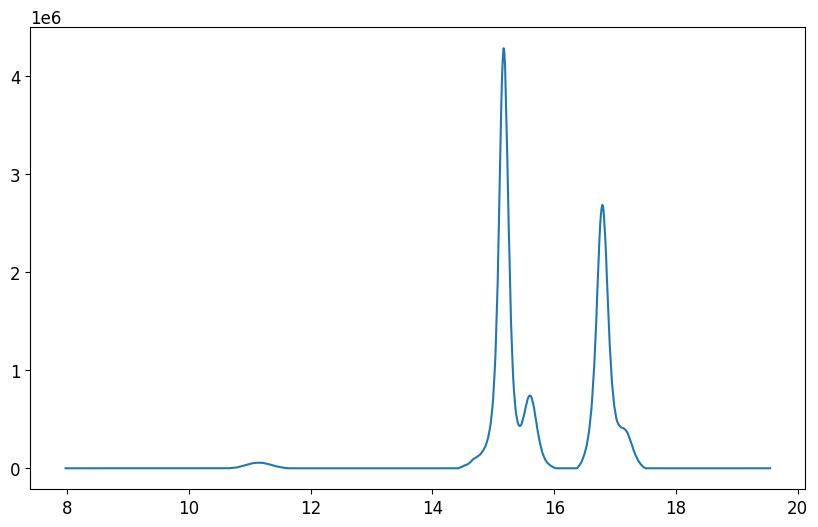

In [550]:
plt.plot(X, (Y - background )* X ** 2)
np.trapezoid((Y - background) * X ** 2, X) / np.trapezoid(Y * X ** 2, X)



##### 6 days

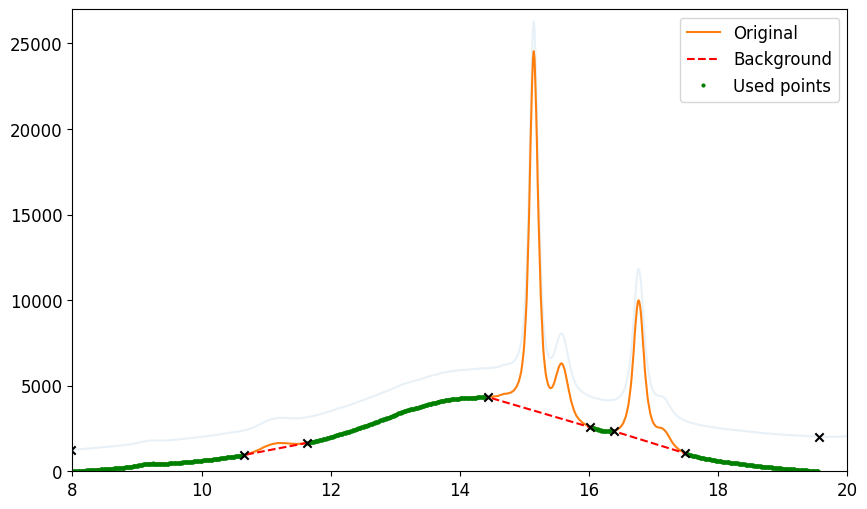

np.float64(0.3024140555492639)

In [559]:
path = r'\\Synology\Data\2025\SC5711\Degradation\Degradation_PCL_5perc_6days_RT'
Exp = BM26_experiment(path)
q, I = Exp.get_1d_WAXS(2)

plt.plot(q, I, alpha=0.1)
l, r = 200, 1150
scatter(q, I, [l, r])
I -= linear_2(q, I, l, r)

X = q[l:r]
Y = I[l:r]

plt.xlim(8, 20)
plt.ylim(0, 1.1 * max(I[:1000]))

l1, r1 = 220, 300
l2, r2 = 530, 660
l3, r3 = 690, 780

scatter(X, Y, [l1, r1, l2, r2, l3, r3])


mask_peaks = np.ones_like(X, dtype=bool)
for l, r in [(l1, r1), (l2, r2), (l3, r3)]:
    mask_peaks &= ~((X >= X[l]) & (X <= X[r]))

spline = PchipInterpolator(X[mask_peaks], Y[mask_peaks], 
                    
                          # extrapolate=False
                         )
# background = spline(q)
background = np.interp(X, X[mask_peaks], Y[mask_peaks])


plt.plot(X, Y, label='Original')
plt.plot(X, background, 'r--', label='Background')
plt.plot(X[mask_peaks], Y[mask_peaks], 'go', markersize=2, label='Used points')
plt.xlim(8, 20)
plt.legend()
plt.show()

cryst(X, Y, background)

np.float64(0.3024140555492639)

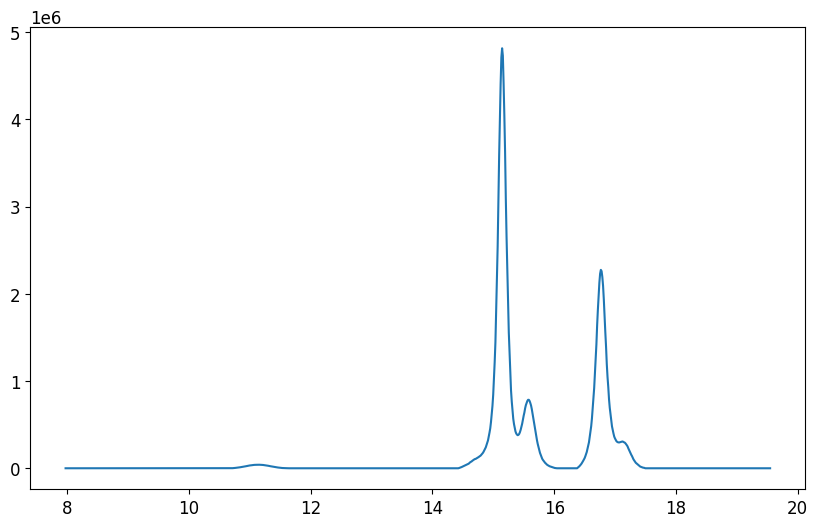

In [552]:
plt.plot(X, (Y - background )* X ** 2)
np.trapezoid((Y - background) * X ** 2, X) / np.trapezoid(Y * X ** 2, X)


##### 14 days

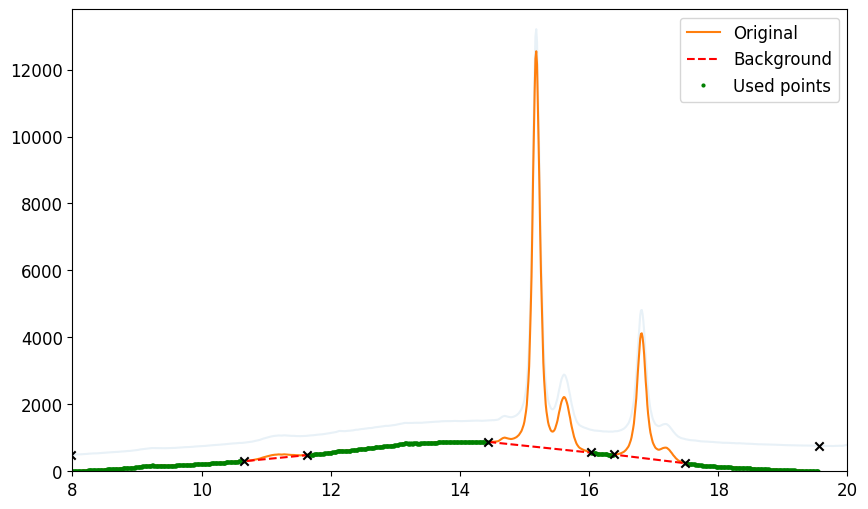

np.float64(0.45259674298663355)

In [560]:
path = r'\\Synology\Data\2025\SC5711\Degradation\Degradation_PCL_5perc_14days_RT'
Exp = BM26_experiment(path)
q, I = Exp.get_1d_WAXS(2)

plt.plot(q, I, alpha=0.1)
l, r = 200, 1150
scatter(q, I, [l, r])
I -= linear_2(q, I, l, r)

X = q[l:r]
Y = I[l:r]

plt.xlim(8, 20)
plt.ylim(0, 1.1 * max(I[:1000]))

l1, r1 = 220, 300
l2, r2 = 530, 660
l3, r3 = 690, 780

scatter(X, Y, [l1, r1, l2, r2, l3, r3])


mask_peaks = np.ones_like(X, dtype=bool)
for l, r in [(l1, r1), (l2, r2), (l3, r3)]:
    mask_peaks &= ~((X >= X[l]) & (X <= X[r]))

spline = PchipInterpolator(X[mask_peaks], Y[mask_peaks], 
                    
                          # extrapolate=False
                         )
# background = spline(q)
background = np.interp(X, X[mask_peaks], Y[mask_peaks])


plt.plot(X, Y, label='Original')
plt.plot(X, background, 'r--', label='Background')
plt.plot(X[mask_peaks], Y[mask_peaks], 'go', markersize=2, label='Used points')
plt.xlim(8, 20)
plt.legend()
plt.show()

cryst(X, Y, background)

np.float64(0.45259674298663355)

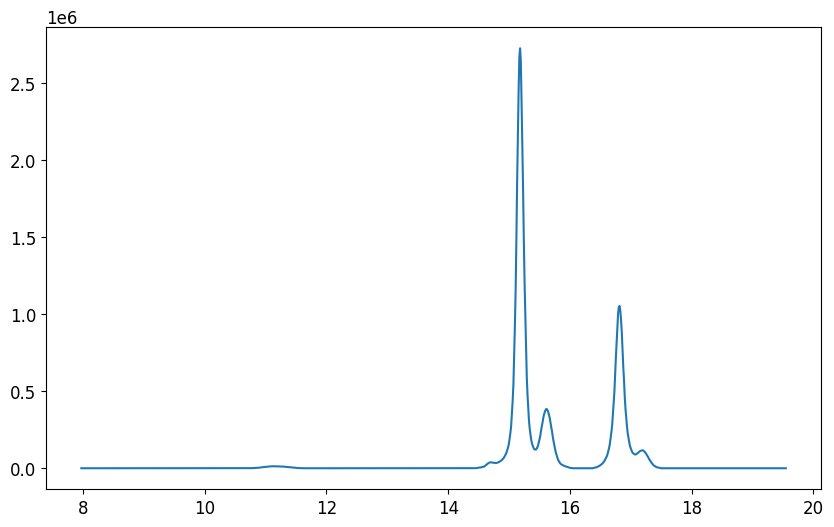

In [554]:
plt.plot(X, (Y - background )* X ** 2)
np.trapezoid((Y - background) * X ** 2, X) / np.trapezoid(Y * X ** 2, X)


### M3 - 10%

##### 3 days

No available WAXS .dat files


IndexError: index 200 is out of bounds for axis 0 with size 0

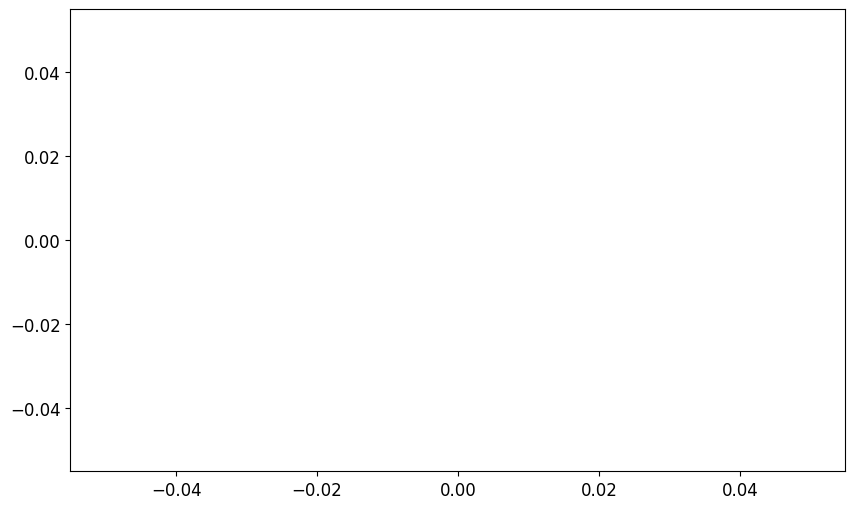

In [563]:
path = r'\\Synology\Data\2025\SC5711\Degradation\Degradation_PCL_10perc_3days_RT'
Exp = BM26_experiment(path)
q, I = Exp.get_1d_WAXS(0)

plt.plot(q, I, alpha=0.1)
l, r = 200, 1150
scatter(q, I, [l, r])
I -= linear_2(q, I, l, r)

X = q[l:r]
Y = I[l:r]

plt.xlim(8, 20)
plt.ylim(0, 1.1 * max(I[:1000]))

l1, r1 = 220, 300
l2, r2 = 530, 660
l3, r3 = 690, 780

scatter(X, Y, [l1, r1, l2, r2, l3, r3])


mask_peaks = np.ones_like(X, dtype=bool)
for l, r in [(l1, r1), (l2, r2), (l3, r3)]:
    mask_peaks &= ~((X >= X[l]) & (X <= X[r]))

spline = PchipInterpolator(X[mask_peaks], Y[mask_peaks], 
                    
                          # extrapolate=False
                         )
# background = spline(q)
background = np.interp(X, X[mask_peaks], Y[mask_peaks])


plt.plot(X, Y, label='Original')
plt.plot(X, background, 'r--', label='Background')
plt.plot(X[mask_peaks], Y[mask_peaks], 'go', markersize=2, label='Used points')
plt.xlim(8, 20)
plt.legend()
plt.show()

cryst(X, Y, background)

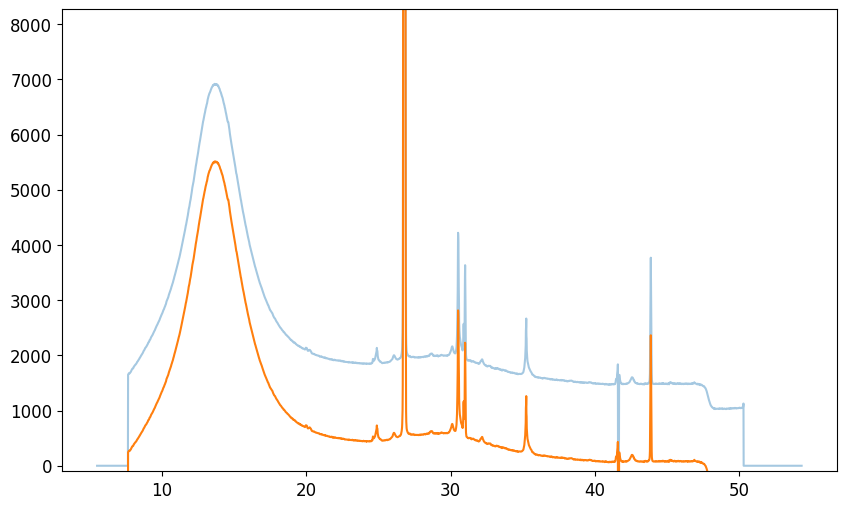

In [354]:
path = r'\\Synology\Data\2025\SC5711\Degradation\Degradation_PCL_M1_3days90C'
Exp = BM26_experiment(path)
q, I = Exp.get_1d_WAXS(1)
plt.plot(q, I, alpha=0.4)

X_amorph, Y_amorph = q, I

p = 200
# plt.scatter(X_amorph[p], Y_amorph[p])
Y_amorph -= 0.8 * Y_amorph[200]

plt.plot(X_amorph, Y_amorph)
# plt.plot(q, const(q, 0), linestyle='--', color='grey')

plt.ylim(-100, 1.5 * max(Y_amorph[:1000]))

interp = interp1d(X_amorph, Y_amorph, kind='cubic', bounds_error=False, fill_value=0)

def halo(x, shift, scale):
    q_shifted = x - shift
    I = interp(q_shifted)
    I[(q_shifted < q_amorph[0]) | (q_shifted > q_amorph[-1])] = 0
    return scale * I

func_lib = {
    'gaussian': gaussian,
    'voigt': voigt,
    'halo': halo,
    'const': const
}

np.float64(182.217186052031)

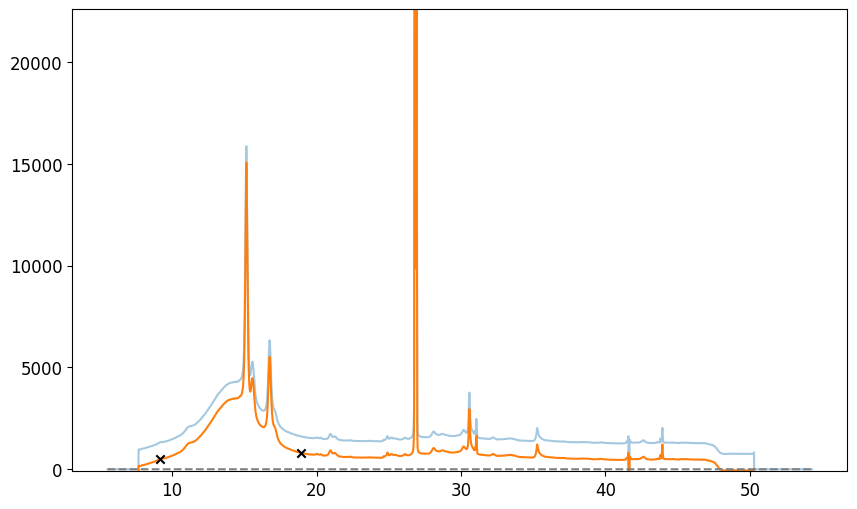

In [361]:
path = r'\\Synology\Data\2025\SC5711\Degradation\Degradation_PCL_M1_3daysRT'
Exp = BM26_experiment(path)
q, I = Exp.get_1d_WAXS(2)
plt.plot(q, I, alpha = 0.4)

X_cryst, Y_cryst = q, I
Y_cryst -= 0.8 * Y_cryst[200]

plt.plot(X_cryst, Y_cryst)
plt.plot(q, const(q, 0), linestyle='--', color='grey')

l, r = 300, 1100

X, Y = X_cryst[l:r], Y_cryst[l:r]
plt.scatter([X[0], X[-1]], [Y[0], Y[-1]], color='black', marker='x', zorder=19)

plt.ylim(-100, 1.5 * max(Y_cryst[:1000]))
0.9 * Y_cryst[200]

In [362]:
# Было:
f_M1_3days = Fitter(X, Y, func_lib)

# Загружаем параметры из предыдущего фиттера (f_old)
# f_M1_3days.set_params(f_M1.get_params())

In [369]:
areas = f_M1_3days.integrals()           # площади ∫ y dx
moments = f_M1_3days.moments()            # моменты ∫ y * x² dx

All = np.sum(moments[:-1])
Cr = np.sum(moments[1:-1])
Cr / All

np.float64(0.24660868260788116)

#### 6 days

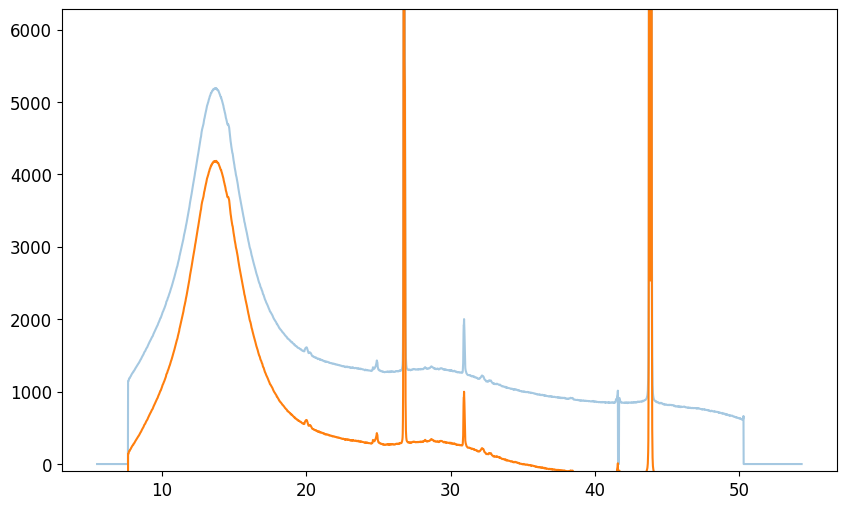

In [381]:
path = r'\\Synology\Data\2025\SC5711\Degradation\Degradation_PCL_M1_6days90C'
Exp = BM26_experiment(path)
q, I = Exp.get_1d_WAXS(1)
plt.plot(q, I, alpha=0.4)

X_amorph, Y_amorph = q, I

p = 200
# plt.scatter(X_amorph[p], Y_amorph[p])
Y_amorph -= 0.8 * Y_amorph[200]

plt.plot(X_amorph, Y_amorph)
# plt.plot(q, const(q, 0), linestyle='--', color='grey')

plt.ylim(-100, 1.5 * max(Y_amorph[:1000]))

interp = interp1d(X_amorph, Y_amorph, kind='cubic', bounds_error=False, fill_value=0)

def halo(x, shift, scale):
    q_shifted = x - shift
    I = interp(q_shifted)
    I[(q_shifted < q_amorph[0]) | (q_shifted > q_amorph[-1])] = 0
    return scale * I

func_lib = {
    'gaussian': gaussian,
    'voigt': voigt,
    'halo': halo,
    'const': const
}

np.float64(223.8807103025534)

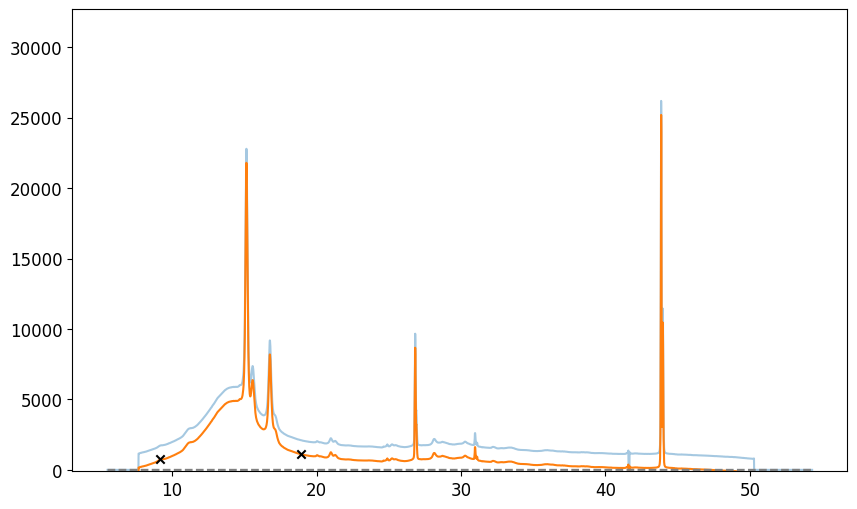

In [382]:
path = r'\\Synology\Data\2025\SC5711\Degradation\Degradation_PCL_M1_6daysRT'
Exp = BM26_experiment(path)
q, I = Exp.get_1d_WAXS(0)
plt.plot(q, I, alpha = 0.4)

X_cryst, Y_cryst = q, I
Y_cryst -= 0.8 * Y_cryst[200]

plt.plot(X_cryst, Y_cryst)
plt.plot(q, const(q, 0), linestyle='--', color='grey')

l, r = 300, 1100

X, Y = X_cryst[l:r], Y_cryst[l:r]
plt.scatter([X[0], X[-1]], [Y[0], Y[-1]], color='black', marker='x', zorder=19)

plt.ylim(-100, 1.5 * max(Y_cryst[:1000]))
0.9 * Y_cryst[200]

In [384]:
f_M1_6days = Fitter(X, Y, func_lib)

# Загружаем параметры из предыдущего фиттера (f_old)
f_M1_6days.set_params(f_M1_3days.get_params())

In [385]:
areas = f_M1_6days.integrals()           # площади ∫ y dx
moments = f_M1_6days.moments()            # моменты ∫ y * x² dx

All = np.sum(moments[:-1])
Cr = np.sum(moments[1:-1])
Cr / All

np.float64(0.24538295282928863)

#### 14 days

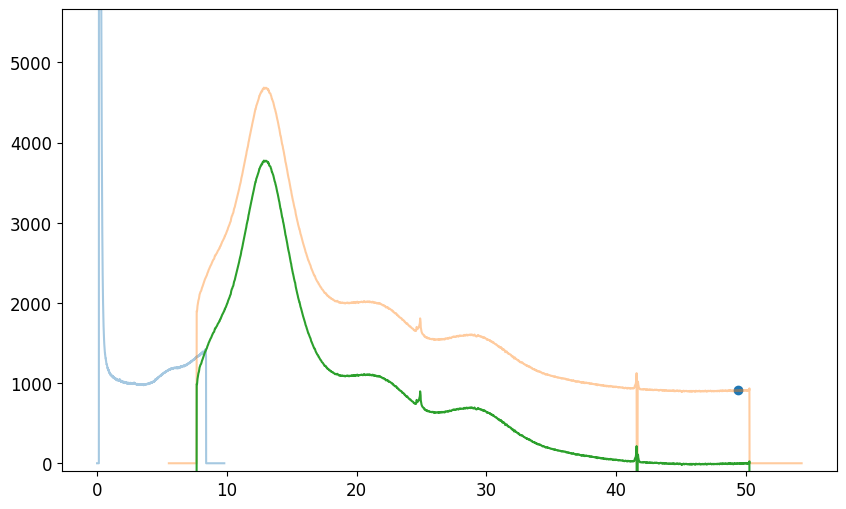

In [426]:
path = r'\\Synology\Data\2025\SC5711\Degradation\Degradation_PCL_M1_14days90C'
Exp = BM26_experiment(path)

q, I = Exp.get_1d_SAXS(1)
plt.plot(q, I * 50, alpha=0.4)
q, I = Exp.get_1d_WAXS(1)
plt.plot(q, I, alpha=0.4)

X_amorph, Y_amorph = q, I

p = -400
plt.scatter(X_amorph[p], Y_amorph[p])
Y_amorph -=  Y_amorph[p]

plt.plot(X_amorph, Y_amorph)
# plt.plot(q, const(q, 0), linestyle='--', color='grey')

plt.ylim(-100, 1.5 * max(Y_amorph[:1000]))

interp = interp1d(X_amorph, Y_amorph, kind='cubic', bounds_error=False, fill_value=0)

def halo(x, shift, scale):
    q_shifted = x - shift
    I = interp(q_shifted)
    I[(q_shifted < q_amorph[0]) | (q_shifted > q_amorph[-1])] = 0
    return scale * I

func_lib = {
    'gaussian': gaussian,
    'voigt': voigt,
    'halo': halo,
    'const': const
}

np.float64(826.9420667698099)

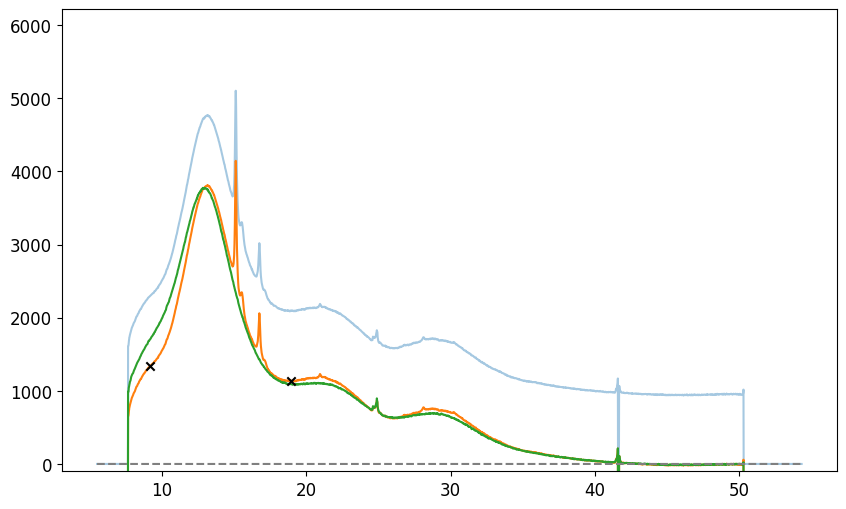

In [427]:
path = r'\\Synology\Data\2025\SC5711\Degradation\Degradation_PCL_M1_14daysRT'
Exp = BM26_experiment(path)
q, I = Exp.get_1d_WAXS(0)
plt.plot(q, I, alpha = 0.4)

X_cryst, Y_cryst = q, I
Y_cryst -=  Y_cryst[p]

plt.plot(X_cryst, Y_cryst)
plt.plot(X_amorph, Y_amorph)
plt.plot(q, const(q, 0), linestyle='--', color='grey')

l, r = 300, 1100

X, Y = X_cryst[l:r], Y_cryst[l:r]
plt.scatter([X[0], X[-1]], [Y[0], Y[-1]], color='black', marker='x', zorder=19)

plt.ylim(-100, 1.5 * max(Y_cryst[:1000]))
0.9 * Y_cryst[200]

In [406]:
f_M1_14days = Fitter(X, Y, func_lib)

# Загружаем параметры из предыдущего фиттера (f_old)
# f_M1_14days.set_params(f_M1_6days.get_params())

In [410]:
areas = f_M1_14days.integrals()           # площади ∫ y dx
moments = f_M1_14days.moments()            # моменты ∫ y * x² dx

All = np.sum(moments[1:])
Cr = np.sum(moments[2:])
Cr / All

np.float64(0.07127266342823013)

### 5%

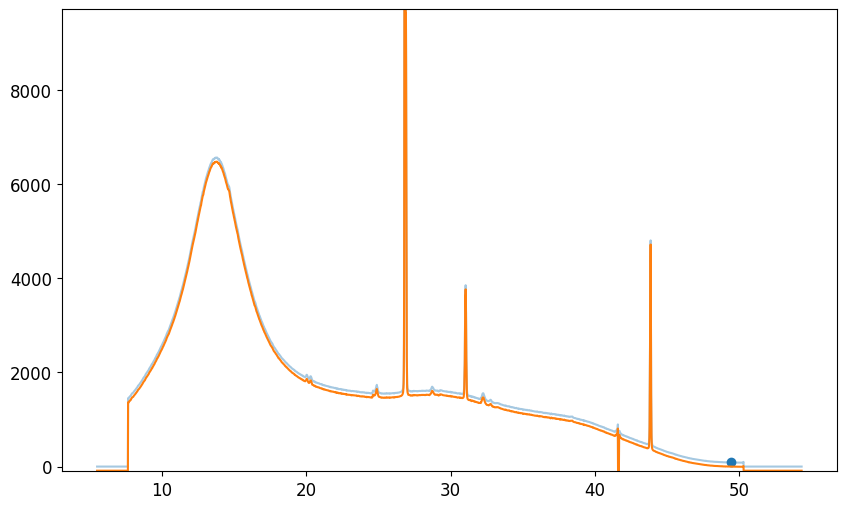

In [416]:
path = r'\\Synology\Data\2025\SC5711\Degradation\Degradation_PCL_5perc_3days_90C'
Exp = BM26_experiment(path)
q, I = Exp.get_1d_WAXS(1)
plt.plot(q, I, alpha=0.4)

X_amorph, Y_amorph = q, I

p = -400
plt.scatter(X_amorph[p], Y_amorph[p])
Y_amorph -=  Y_amorph[p]

plt.plot(X_amorph, Y_amorph)
# plt.plot(q, const(q, 0), linestyle='--', color='grey')

plt.ylim(-100, 1.5 * max(Y_amorph[:1000]))

interp = interp1d(X_amorph, Y_amorph, kind='cubic', bounds_error=False, fill_value=0)

def halo(x, shift, scale):
    q_shifted = x - shift
    I = interp(q_shifted)
    I[(q_shifted < q_amorph[0]) | (q_shifted > q_amorph[-1])] = 0
    return scale * I

func_lib = {
    'gaussian': gaussian,
    'voigt': voigt,
    'halo': halo,
    'const': const
}

### Exps

(0.0, 4000.0)

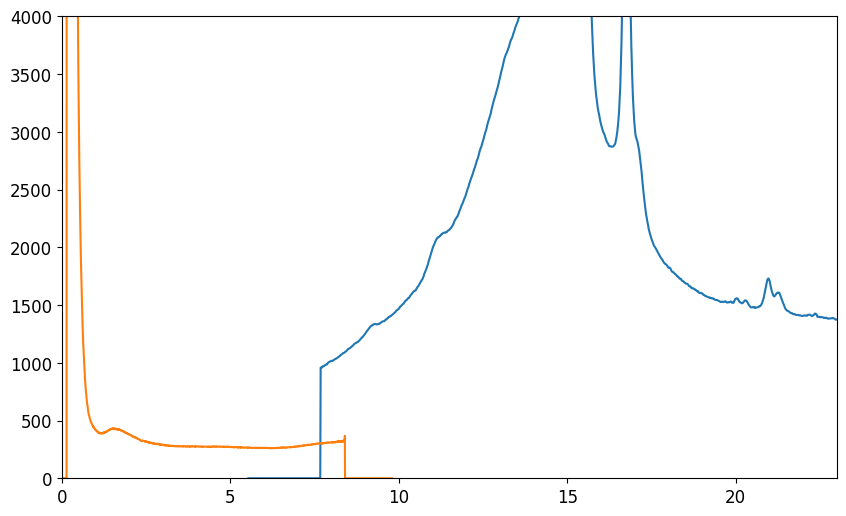

In [342]:
path = r'\\Synology\Data\2025\SC5711\Degradation\Degradation_PCL_M1_3daysRT'
Exp = BM26_experiment(path)

q_saxs, I_saxs = Exp.get_1d_SAXS(1)
q_waxs, I_waxs = Exp.get_1d_WAXS(1)

plt.plot(q_waxs, I_waxs)
plt.plot(q_saxs, I_saxs * 30)

plt.xlim(0, 23)
plt.ylim(0, 0.4e4)

In [305]:
import plotly.graph_objects as go

(0.0, 10000.0)

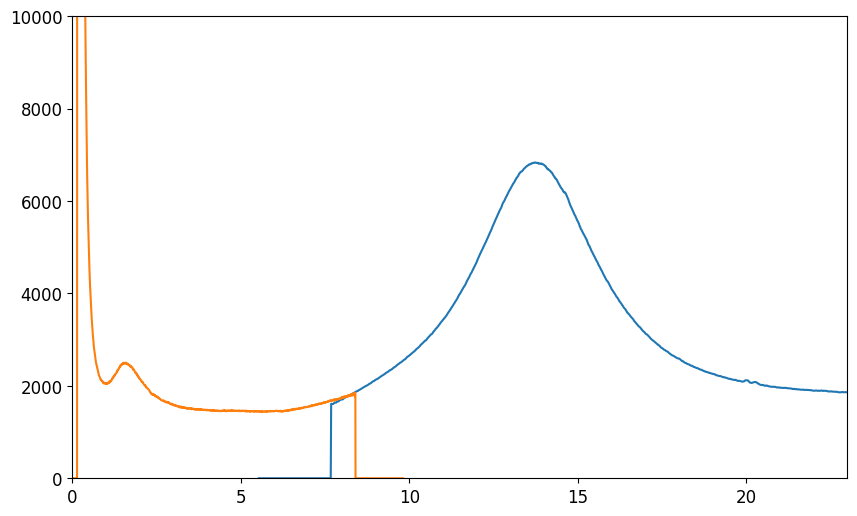

In [310]:
path = r'\\Synology\Data\2025\SC5711\Degradation\Degradation_PCL_M1_3days90C'
Exp = BM26_experiment(path)

q_saxs, I_saxs = Exp.get_1d_SAXS()
q_waxs, I_waxs = Exp.get_1d_WAXS()

plt.plot(q_saxs, I_saxs * 94)

plt.xlim(0, 23)
plt.ylim(0, 1e4)

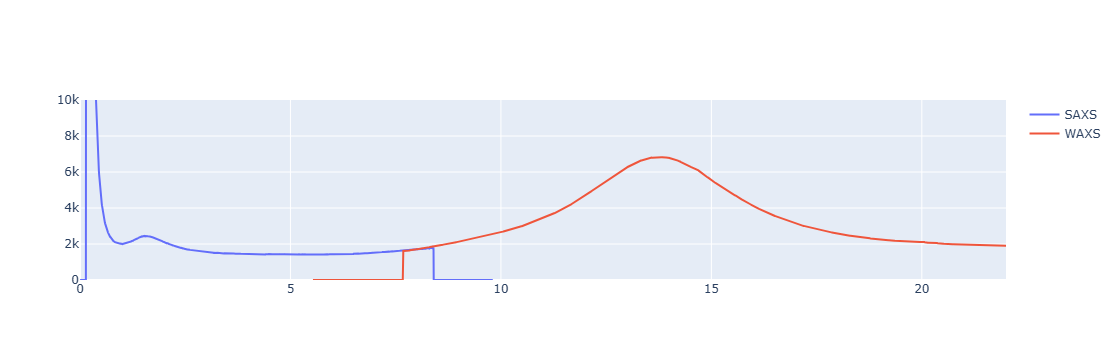

In [311]:
fig = go.Figure()
fig.add_trace(go.Scatter(x=q_saxs, y=I_saxs * 92, mode='lines', name='SAXS'))
fig.add_trace(go.Scatter(x=q_waxs, y=I_waxs, mode='lines', name='WAXS'))
fig.update_layout(xaxis_range=[0, 22], yaxis_range=[0, 1e4])
fig.show()

(0.0, 10000.0)

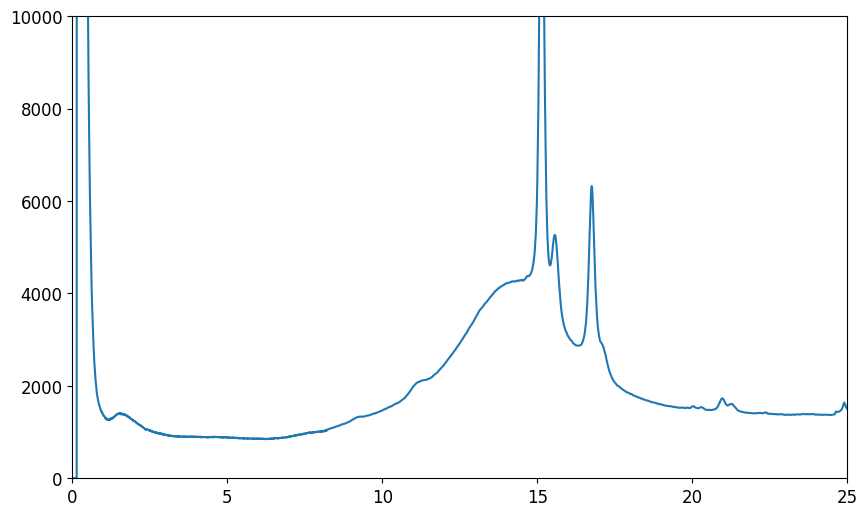

In [417]:
mask = (q_waxs > 7.8) & (q_waxs < 8.2)

I_saxs_interp = np.interp(q_waxs[mask], q_saxs, I_saxs)
scale = np.mean(I_waxs[mask] / I_saxs_interp)


I_saxs_scaled = I_saxs * scale

join_idx_saxs = np.argmax(q_saxs > 8.2)
join_idx_waxs = np.argmax(q_waxs > 8.2)

q_merged = np.concatenate([q_saxs[:join_idx_saxs], q_waxs[join_idx_waxs:]])
I_merged = np.concatenate([I_saxs_scaled[:join_idx_saxs], I_waxs[join_idx_waxs:]])

plt.plot(q_merged, I_merged)
plt.xlim(0, 25)
plt.ylim(0, 1e4)

# l, r = 1200, 3000
# plt.scatter([q_merged[l], q_merged[r]], [I_merged[l], I_merged[r]], marker='x', color='black')

# plt.plot(q_merged, linear_2points(q_merged,q_merged[l], I_merged[l], q_merged[r], I_merged[r]))

(0.0, 6000.0)

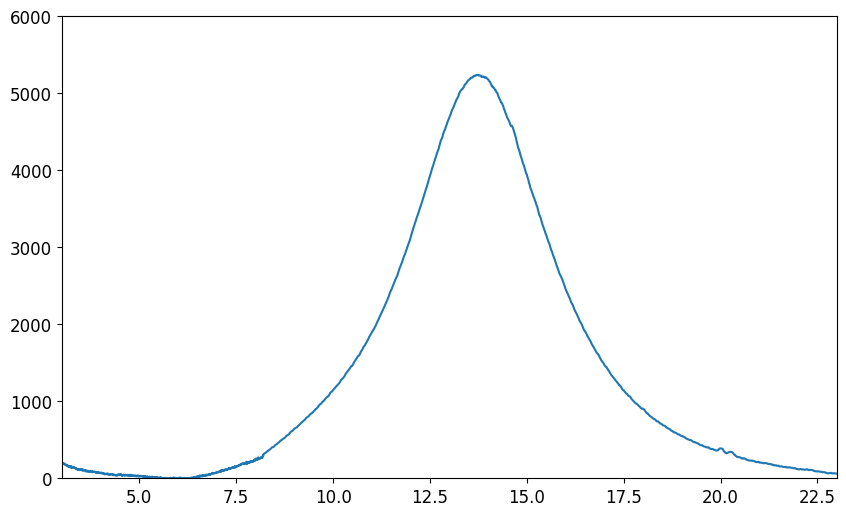

In [334]:
plt.plot(q_merged, I_merged - linear_2points(q_merged,q_merged[l], I_merged[l], q_merged[r], I_merged[r]))
plt.xlim(3, 23)
plt.ylim(0, 0.6e4)

### M1

##### 3days

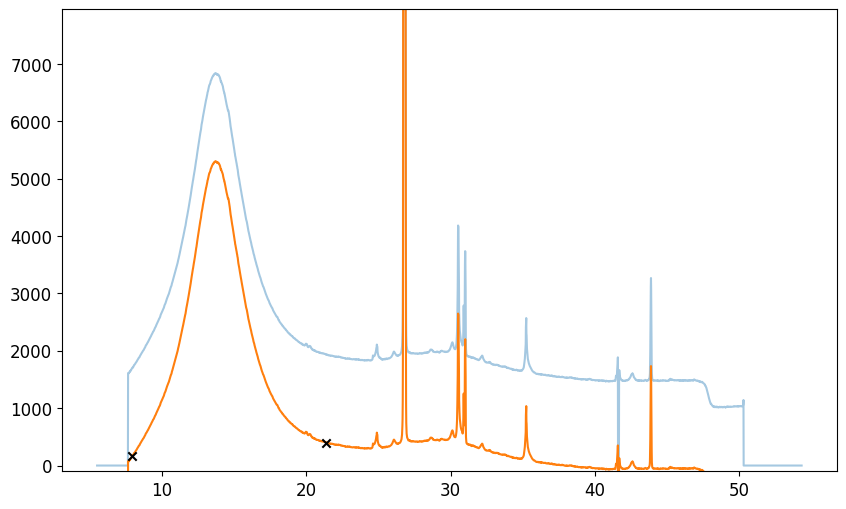

In [275]:
path = r'\\Synology\Data\2025\SC5711\Degradation\Degradation_PCL_M1_3days90C'
Exp = BM26_experiment(path)
q, I = Exp.get_1d_WAXS()
plt.plot(q, I, alpha=0.4)

X_amorph, Y_amorph = q, I

p = 200
# plt.scatter(X_amorph[p], Y_amorph[p])
Y_amorph -= 0.9 * Y_amorph[200]

plt.plot(X_amorph, Y_amorph)
# plt.plot(q, const(q, 0), linestyle='--', color='grey')

plt.ylim(-100, 1.5 * max(Y_amorph[:1000]))

l, r = 200, 1300

X, Y = X_amorph[l:r], Y_amorph[l:r]
plt.scatter([X[0], X[-1]], [Y[0], Y[-1]], color='black', marker='x', zorder=19)


X_0, Y_0 = X, (Y - linear_2points(X, X[0], Y[0], X[-1], Y[-1])) * X ** 2

(0.0, 5000000.0)

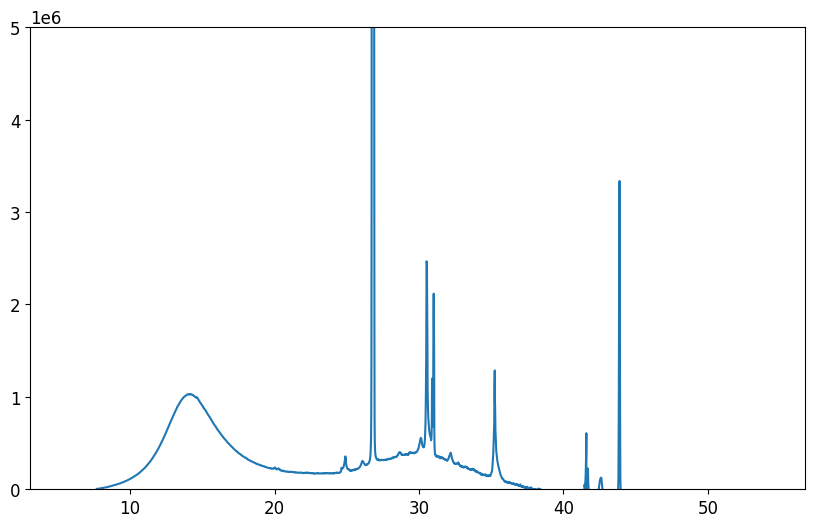

In [281]:
# plt.plot(X_0, Y_0)

# model = voigt
# p, cov = curve_fit(model, X_0, Y_0, p0=[1e6, 14, 1, 1])
# plt.plot(X_0, model(X_0, *p))

plt.plot(X_amorph, Y_amorph * X_amorph ** 2)
plt.ylim(0, 0.5e7)

np.float64(283.9672778121173)

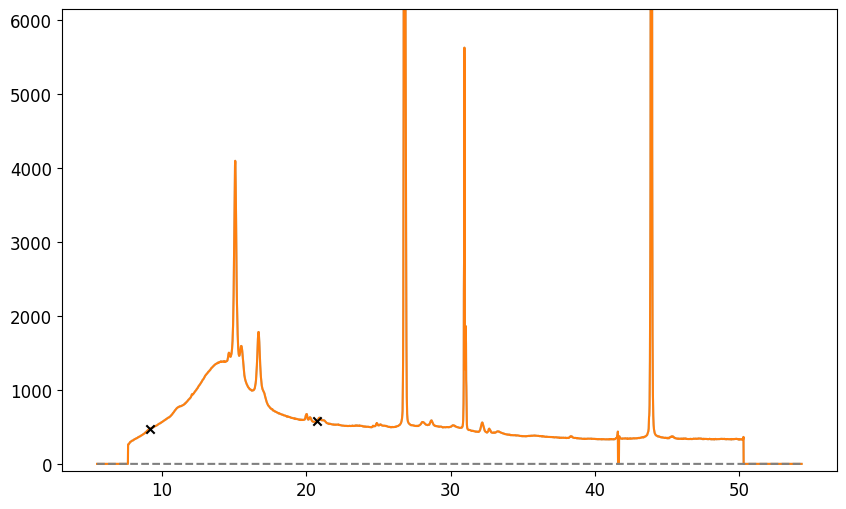

In [255]:
path = r'\\Synology\Data\2025\SC5711\Degradation\Degradation_PCL_M1_3daysRT'
Exp = BM26_experiment(path)
q, I = Exp.get_1d_WAXS()
plt.plot(q, I, alpha = 0.4)

X_cryst, Y_cryst = q, I
# Y_cryst -= 0.9 * Y_cryst[200]

plt.plot(X_cryst, Y_cryst)
plt.plot(q, const(q, 0), linestyle='--', color='grey')

interp = interp1d(X_amorph, Y_amorph, kind='cubic', bounds_error=False, fill_value=0)

def halo(x, shift, scale):
    q_shifted = x - shift
    I = interp(q_shifted)
    I[(q_shifted < q_amorph[0]) | (q_shifted > q_amorph[-1])] = 0
    return scale * I

func_lib = {
    'gaussian': gaussian,
    'voigt': voigt,
    'halo': halo,
    'const': const
}
l, r = 300, 1250

X, Y = X_cryst[l:r], Y_cryst[l:r]
plt.scatter([X[0], X[-1]], [Y[0], Y[-1]], color='black', marker='x', zorder=19)

plt.ylim(-100, 1.5 * max(Y_cryst[:1000]))
0.9 * Y_cryst[200]

In [256]:
# Было:
f_M1_3days = Fitter(X, Y, func_lib)

# Загружаем параметры из предыдущего фиттера (f_old)
# f_M1_3days.set_params(f_M1.get_params())

In [235]:
areas = f_M1_3days.integrals()           # площади ∫ y dx
moments = f_M1_3days.moments()            # моменты ∫ y * x² dx

All = np.sum(moments[1:])
Cr = np.sum(moments[2:])
Cr / All

np.float64(0.2178237158115297)

In [236]:
areas

[np.float64(5317.777913591381),
 np.float64(4727.242019858704),
 np.float64(672.1683598797666),
 np.float64(265.95419439242204),
 np.float64(103.35427300869814),
 np.float64(73.23104340273208),
 np.float64(9.822526660218822),
 np.float64(10.026513098524003),
 np.float64(10.026513098524003)]

##### 6days

(-100.0, 6097.519240562685)

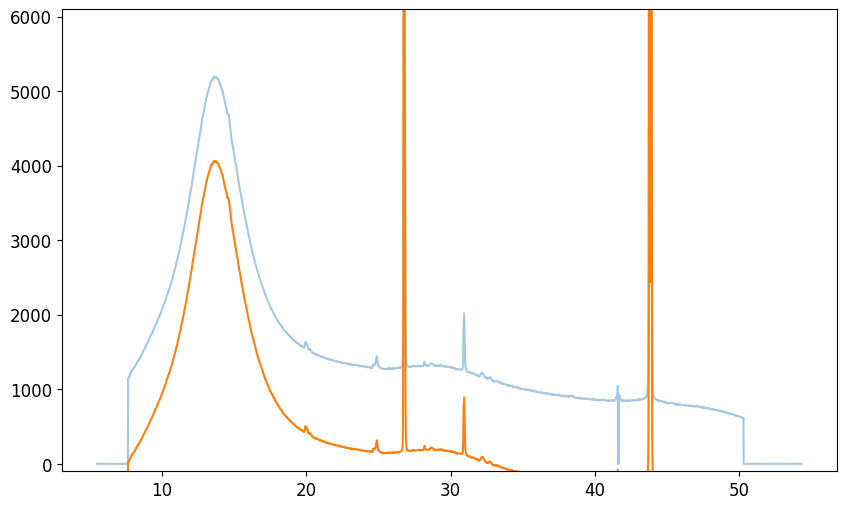

In [237]:
path = r'\\Synology\Data\2025\SC5711\Degradation\Degradation_PCL_M1_6days90C'
Exp = BM26_experiment(path)
q, I = Exp.get_1d_WAXS()
plt.plot(q, I, alpha=0.4)

X_amorph, Y_amorph = q, I

p = 200
# plt.scatter(X_amorph[p], Y_amorph[p])
Y_amorph -= 0.9 * Y_amorph[200]

plt.plot(X_amorph, Y_amorph)
# plt.plot(q, const(q, 0), linestyle='--', color='grey')

plt.ylim(-100, 1.5 * max(Y_amorph[:1000]))



np.float64(1119.403551512767)

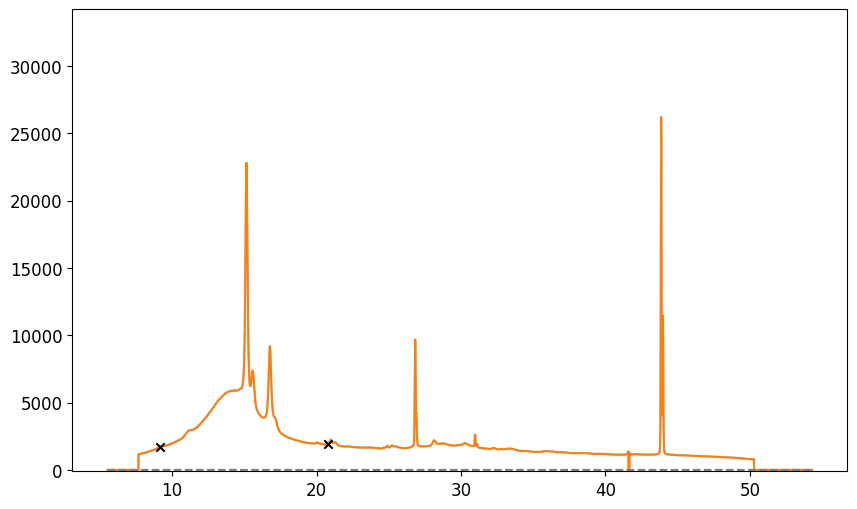

In [238]:
path = r'\\Synology\Data\2025\SC5711\Degradation\Degradation_PCL_M1_6daysRT'
Exp = BM26_experiment(path)
q, I = Exp.get_1d_WAXS()
plt.plot(q, I, alpha = 0.4)

X_cryst, Y_cryst = q, I
# Y_cryst -= 0.9 * Y_cryst[200]

plt.plot(X_cryst, Y_cryst)
plt.plot(q, const(q, 0), linestyle='--', color='grey')

interp = interp1d(X_amorph, Y_amorph, kind='cubic', bounds_error=False, fill_value=0)

def halo(x, shift, scale):
    q_shifted = x - shift
    I = interp(q_shifted)
    I[(q_shifted < q_amorph[0]) | (q_shifted > q_amorph[-1])] = 0
    return scale * I

func_lib = {
    'gaussian': gaussian,
    'voigt': voigt,
    'halo': halo,
    'const': const
}
l, r = 300, 1250

X, Y = X_cryst[l:r], Y_cryst[l:r]
plt.scatter([X[0], X[-1]], [Y[0], Y[-1]], color='black', marker='x', zorder=19)

plt.ylim(-100, 1.5 * max(Y_cryst[:1000]))
0.9 * Y_cryst[200]

In [239]:
# Было:
f_M1_6days = Fitter(X, Y, func_lib)

# Загружаем параметры из предыдущего фиттера (f_old)
f_M1_6days.set_params(f_M1_3days.get_params())

In [240]:
areas = f_M1_6days.integrals()           # площади ∫ y dx
moments = f_M1_6days.moments()            # моменты ∫ y * x² dx

All = np.sum(moments[1:])
Cr = np.sum(moments[2:])
Cr / All

np.float64(0.235140560105817)

##### 14days

(-100.0, 4141.348300487607)

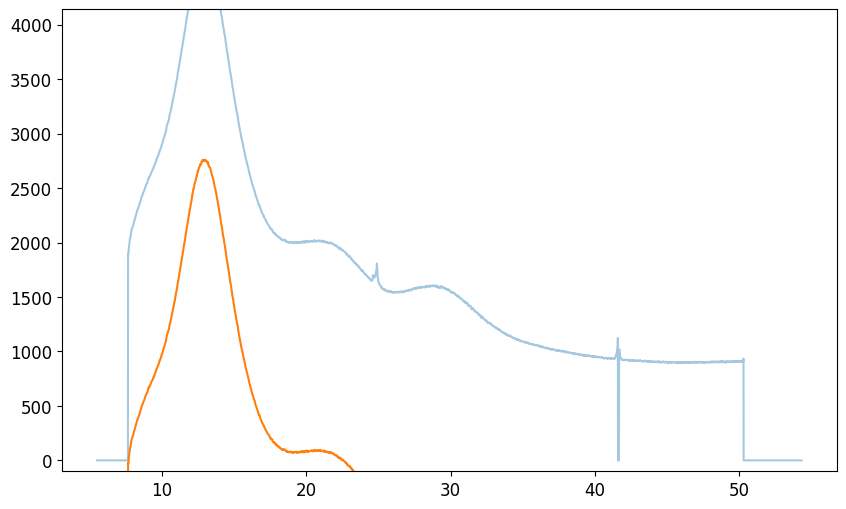

In [245]:
path = r'\\Synology\Data\2025\SC5711\Degradation\Degradation_PCL_M1_14days90C'
Exp = BM26_experiment(path)
q, I = Exp.get_1d_WAXS(1)
plt.plot(q, I, alpha=0.4)

X_amorph, Y_amorph = q, I

p = 200
# plt.scatter(X_amorph[p], Y_amorph[p])
Y_amorph -= 0.9 * Y_amorph[200]

plt.plot(X_amorph, Y_amorph)
# plt.plot(q, const(q, 0), linestyle='--', color='grey')

plt.ylim(-100, 1.5 * max(Y_amorph[:1000]))

np.float64(1689.6366875185422)

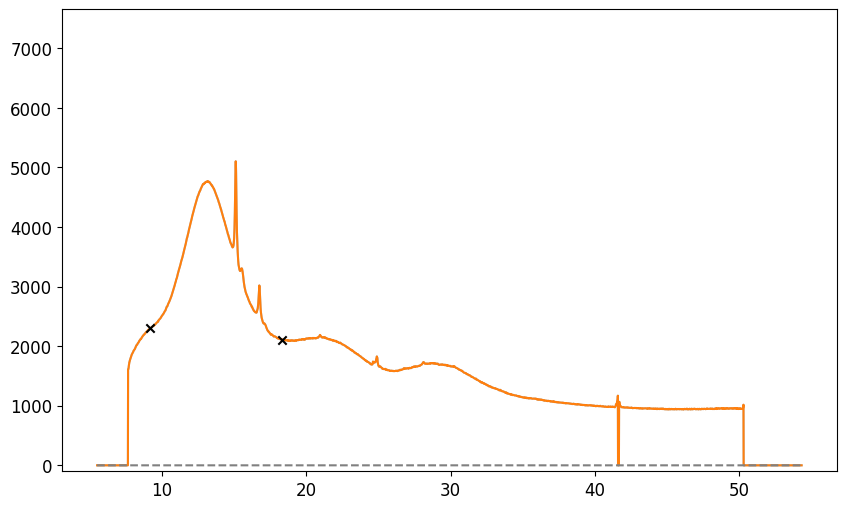

In [250]:
path = r'\\Synology\Data\2025\SC5711\Degradation\Degradation_PCL_M1_14daysRT'
Exp = BM26_experiment(path)
q, I = Exp.get_1d_WAXS()
plt.plot(q, I, alpha = 0.4)

X_cryst, Y_cryst = q, I
# Y_cryst -= 0.9 * Y_cryst[200]

plt.plot(X_cryst, Y_cryst)
plt.plot(q, const(q, 0), linestyle='--', color='grey')

interp = interp1d(X_amorph, Y_amorph, kind='cubic', bounds_error=False, fill_value=0)

def halo(x, shift, scale):
    q_shifted = x - shift
    I = interp(q_shifted)
    I[(q_shifted < q_amorph[0]) | (q_shifted > q_amorph[-1])] = 0
    return scale * I

func_lib = {
    'gaussian': gaussian,
    'voigt': voigt,
    'halo': halo,
    'const': const
}
l, r = 300, 1050

X, Y = X_cryst[l:r], Y_cryst[l:r]
plt.scatter([X[0], X[-1]], [Y[0], Y[-1]], color='black', marker='x', zorder=19)

plt.ylim(-100, 1.5 * max(Y_cryst[:1000]))
0.9 * Y_cryst[200]

In [251]:
# Было:
f_M1_14days = Fitter(X, Y, func_lib)

# Загружаем параметры из предыдущего фиттера (f_old)
f_M1_14days
    .set_params(f_M1_6days.get_params())

In [8]:
f = Fitter(X, Y, func_lib)

In [11]:
areas = f.integrals()           # площади ∫ y dx
moments = f.moments()            # моменты ∫ y * x² dx

All = np.sum(moments[1:])
Cr = np.sum(moments[2:])
Cr / All

np.float64(0.25992990586243175)

In [20]:
Cr_M3 = 0.25992990586243175

In [16]:
# Было:
f_M4 = Fitter(X, Y, func_lib)

# Загружаем параметры из предыдущего фиттера (f_old)
f_M4.set_params(f.get_params())

In [17]:
areas = f_M4.integrals()           # площади ∫ y dx
moments = f_M4.moments()            # моменты ∫ y * x² dx

All = np.sum(moments[1:])
Cr = np.sum(moments[2:])
Cr / All

np.float64(0.30715459332810824)

In [19]:
Cr_M4 = 0.30715459332810824

In [22]:
# Было:
f_M1 = Fitter(X, Y, func_lib)

# Загружаем параметры из предыдущего фиттера (f_old)
f_M1.set_params(f.get_params())

In [23]:
areas = f_M1.integrals()           # площади ∫ y dx
moments = f_M1.moments()            # моменты ∫ y * x² dx

All = np.sum(moments[1:])
Cr = np.sum(moments[2:])
Cr / All

np.float64(0.20554704154767525)

'PCL_M2_100ms_1m_1'

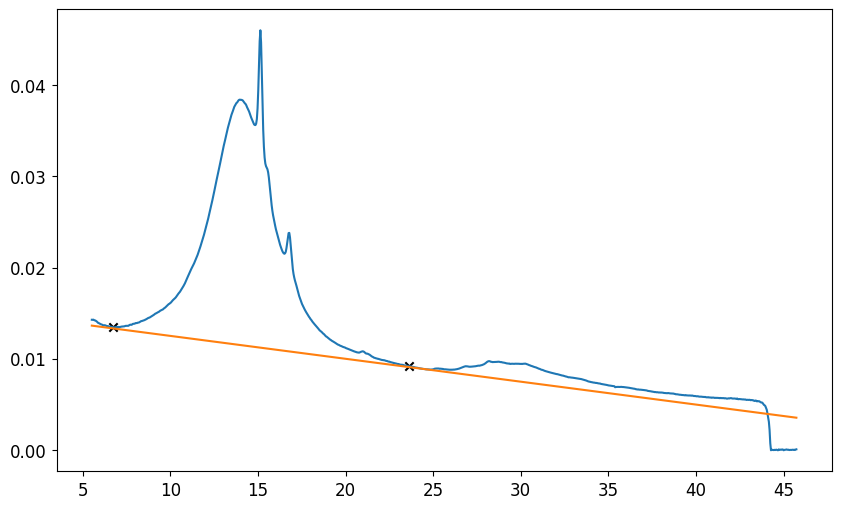

In [189]:
path = r"\\Synology\Data\2025\sc5665\id02\20250404\PROCESSED_DATA\PEG\PEG_20250405-141744\PEG_waxs_00083_00_ave.h5"

Exp = ID02_experiment(path)

q, I = Exp.get_1d_data()


plt.figure(figsize=(10,6))
plt.plot(q, I)

l = 30
r = 450

plt.scatter([q[l], q[r]], [I[l], I[r]], marker='x', color='black')

x = q[l:r]
y = I[l:r]

coef = 0.99

plt.plot(q, linear_2points(q, x[0], y[0], x[-1], y[-1]) * coef)

X = x
Y = y - linear_2points(x, x[0], y[0], x[-1], y[-1]) * coef

Exp.get_Title()

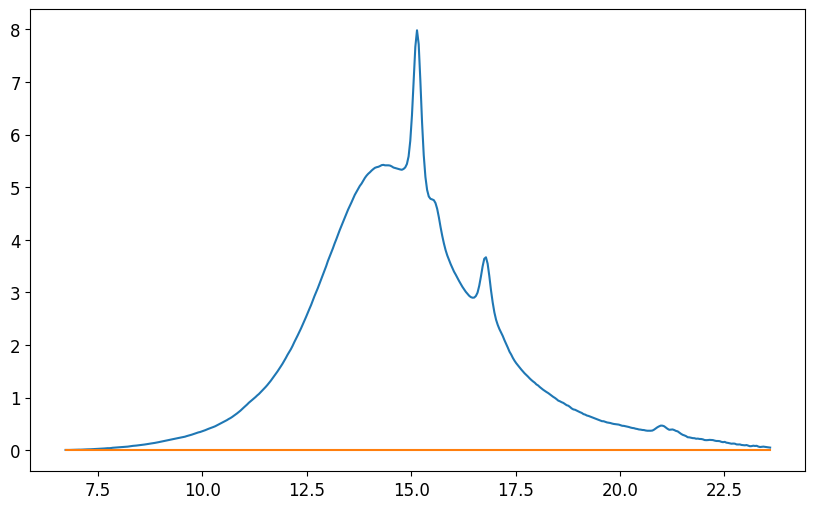

In [190]:
plt.plot(X, Y * X ** 2)
plt.plot(X, np.zeros(len(X)))

X_M2 = X
Y_M2 = Y * X ** 2

In [193]:
# Создаем новый билдер
build_M2 = PeakBuilder(X_M2, Y_M2)

# Очищаем пики по умолчанию
build_M2.peaks = []

# Копируем пики из build_M4 (только то, что есть)
for peak in build_M4.peaks:
    build_M2.peaks.append([
        peak[0],  # x0
        peak[1],  # amp
        peak[2],  # sigma
        peak[3],  # type
        peak[4],  # gamma
        peak[5]   # crystalline
    ])

# Обновляем отображение
build_M2.update_peak_list()
build_M2.update_plot()